In [177]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [43]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import random
import math

from scipy.stats import gamma, expon

# Results.HDF5

In [44]:
# Path
hdf5_file = r"C:\Users\Ribhav\Desktop\UIUC\Classes\Git Repos\Work\MIV_Results\Data\skim449_RC_9_19_24\continuous.result.hdf5"

In [45]:
# Sampling rate in Hz (30 kHz)
sampling_rate = 30000 

In [48]:
# Open the HDF5 file
with h5py.File(hdf5_file, 'r') as f:
    # Find the spike times datasets for each template
    
    print(list(f.keys()))
    
    spiketimes_group = f['spiketimes']  # Group containing spike times for each template
    # template_names = list(spiketimes_group.keys())  # List of template names (e.g., 'temp_0', 'temp_1', ...)
    template_names = sorted(f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))

    # Prepare the data for plotting
    spike_data = []
    for template in template_names:
        spike_times = np.array(spiketimes_group[template]) / sampling_rate # Extract spike times for this template
        spike_data.append(spike_times)

['amplitudes', 'info', 'spiketimes']


In [49]:
len(spike_data)

171

In [50]:
template_names

['temp_0',
 'temp_1',
 'temp_2',
 'temp_3',
 'temp_4',
 'temp_5',
 'temp_6',
 'temp_7',
 'temp_8',
 'temp_9',
 'temp_10',
 'temp_11',
 'temp_12',
 'temp_13',
 'temp_14',
 'temp_15',
 'temp_16',
 'temp_17',
 'temp_18',
 'temp_19',
 'temp_20',
 'temp_21',
 'temp_22',
 'temp_23',
 'temp_24',
 'temp_25',
 'temp_26',
 'temp_27',
 'temp_28',
 'temp_29',
 'temp_30',
 'temp_31',
 'temp_32',
 'temp_33',
 'temp_34',
 'temp_35',
 'temp_36',
 'temp_37',
 'temp_38',
 'temp_39',
 'temp_40',
 'temp_41',
 'temp_42',
 'temp_43',
 'temp_44',
 'temp_45',
 'temp_46',
 'temp_47',
 'temp_48',
 'temp_49',
 'temp_50',
 'temp_51',
 'temp_52',
 'temp_53',
 'temp_54',
 'temp_55',
 'temp_56',
 'temp_57',
 'temp_58',
 'temp_59',
 'temp_60',
 'temp_61',
 'temp_62',
 'temp_63',
 'temp_64',
 'temp_65',
 'temp_66',
 'temp_67',
 'temp_68',
 'temp_69',
 'temp_70',
 'temp_71',
 'temp_72',
 'temp_73',
 'temp_74',
 'temp_75',
 'temp_76',
 'temp_77',
 'temp_78',
 'temp_79',
 'temp_80',
 'temp_81',
 'temp_82',
 'temp_83',
 '

In [51]:
spike_data

[array([1.34233333e-01, 1.15390000e+00, 1.17750000e+00, ...,
        7.20961780e+03, 7.20978437e+03, 7.21039400e+03]),
 array([1.49543333e+00, 1.50450000e+00, 1.52876667e+00, ...,
        7.20958737e+03, 7.20976507e+03, 7.20979427e+03]),
 array([3.29133333e-01, 1.13043333e+00, 1.15686667e+00, ...,
        7.20892667e+03, 7.20907877e+03, 7.20953523e+03]),
 array([1.08516667e+00, 1.10036667e+00, 1.10320000e+00, ...,
        7.20895497e+03, 7.20895773e+03, 7.20897023e+03]),
 array([1.35206667e+00, 1.44146667e+00, 1.45246667e+00, ...,
        7.20458213e+03, 7.20459700e+03, 7.20870950e+03]),
 array([3.66366667e-01, 9.25000000e-01, 1.16076667e+00, ...,
        7.20989983e+03, 7.20993763e+03, 7.21006157e+03]),
 array([1.08406667e+00, 1.09490000e+00, 1.10310000e+00, ...,
        7.20995747e+03, 7.21002487e+03, 7.21039100e+03]),
 array([1.15640000e+00, 1.36033333e+00, 1.38443333e+00, ...,
        7.20881060e+03, 7.20926443e+03, 7.20961927e+03]),
 array([1.50816667e+00, 1.51106667e+00, 5.187033

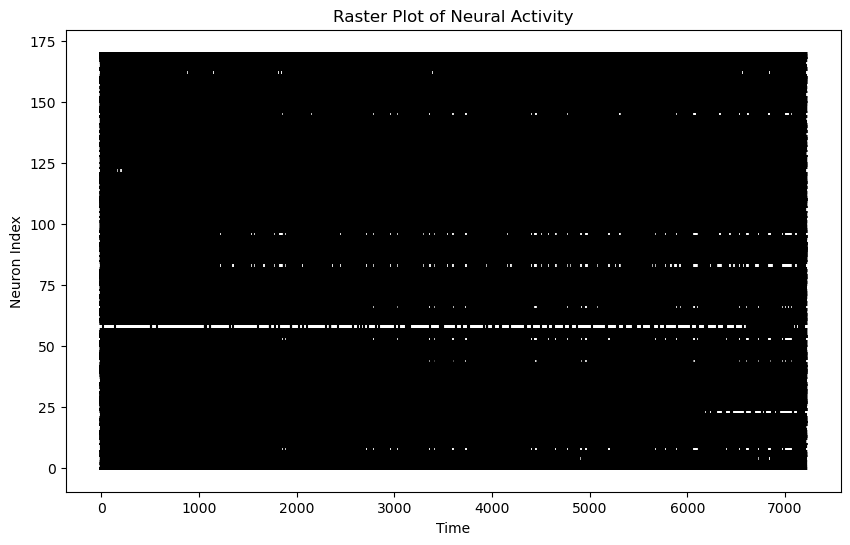

In [8]:
plt.figure(figsize=(10, 6))
plt.eventplot(spike_data, colors='black')

# Label the plot
plt.xlabel('Time')
plt.ylabel('Neuron Index')
plt.title('Raster Plot of Neural Activity')

# Display the plot
plt.show()

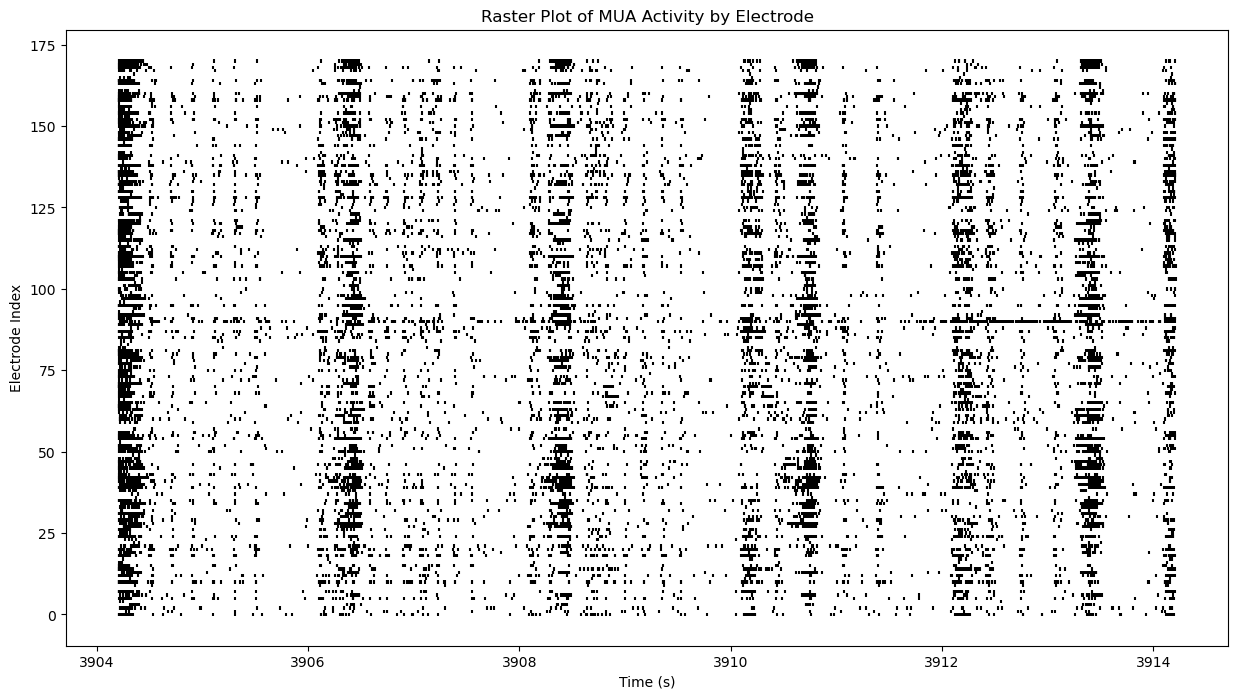

In [46]:
start_time = 3904.20996666
end_time = 3914.20996666

spike_data = []
with h5py.File(hdf5_file, 'r') as f:
    electrode_names = sorted(f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))
    for electrode in electrode_names:
        spike_times = np.array(f['spiketimes'][electrode]) / sampling_rate  # Convert to seconds

        mask = (spike_times >= start_time) & (spike_times <= end_time)
        filtered_spike_times = spike_times[mask]        

        spike_data.append(filtered_spike_times)

plt.figure(figsize=(15, 8))
plt.eventplot(spike_data, colors='black')
plt.xlabel('Time (s)')
plt.ylabel('Electrode Index')
plt.title('Raster Plot of MUA Activity by Electrode')
plt.show()


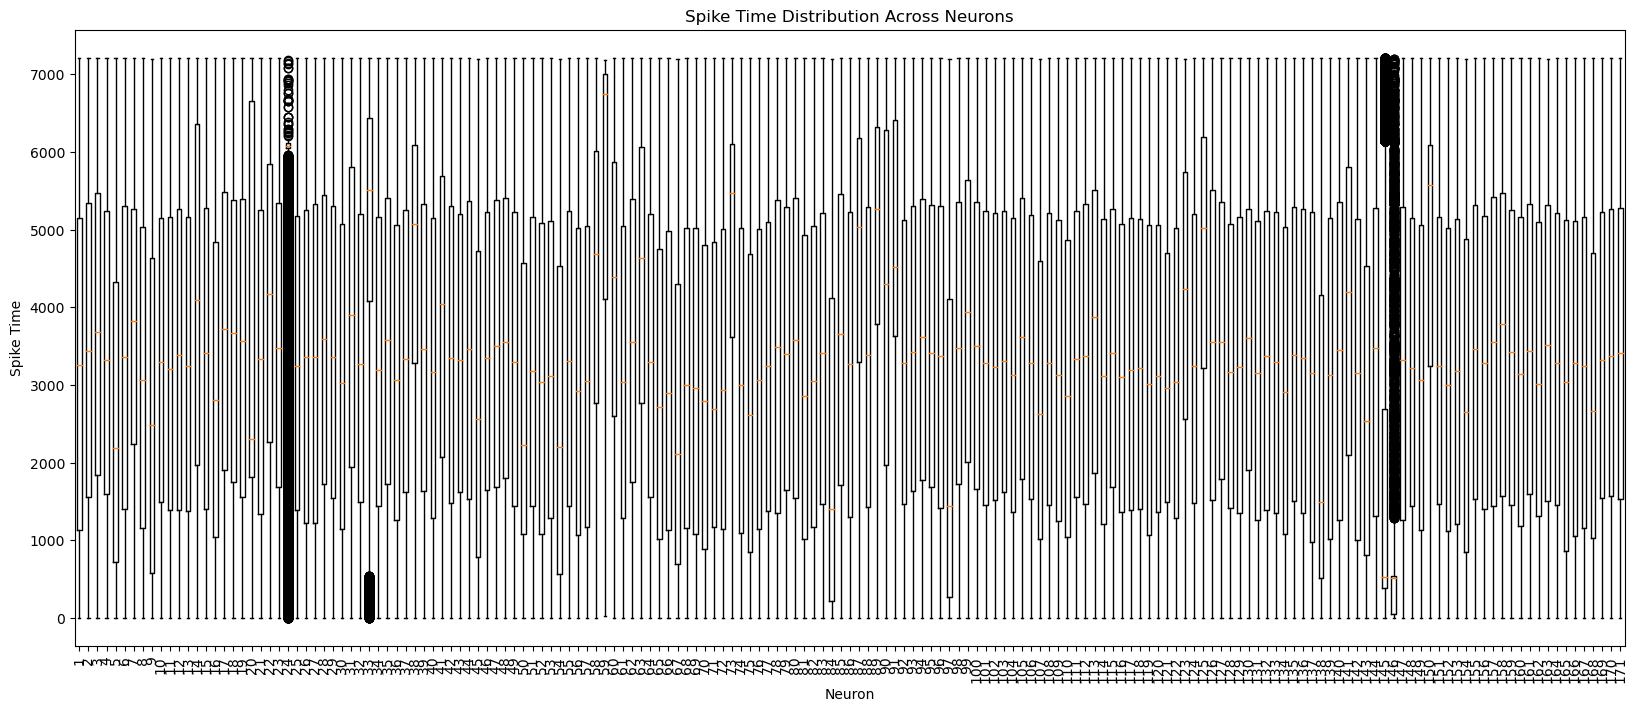

In [52]:
spike_data = []

with h5py.File(hdf5_file, 'r') as f:
    template_names = sorted(f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))
    for template in template_names:
        spike_times = np.array(f['spiketimes'][template]) / sampling_rate  # Convert to seconds
        spike_data.append(spike_times)

plt.figure(figsize=(20, 8))
plt.boxplot(spike_data, vert=True, showfliers=True)
plt.xticks(rotation=90)
plt.xlabel('Neuron')
plt.ylabel('Spike Time')
plt.title('Spike Time Distribution Across Neurons')
plt.show()

## Spike Amplitude Distribution (Histogram) - One Plot

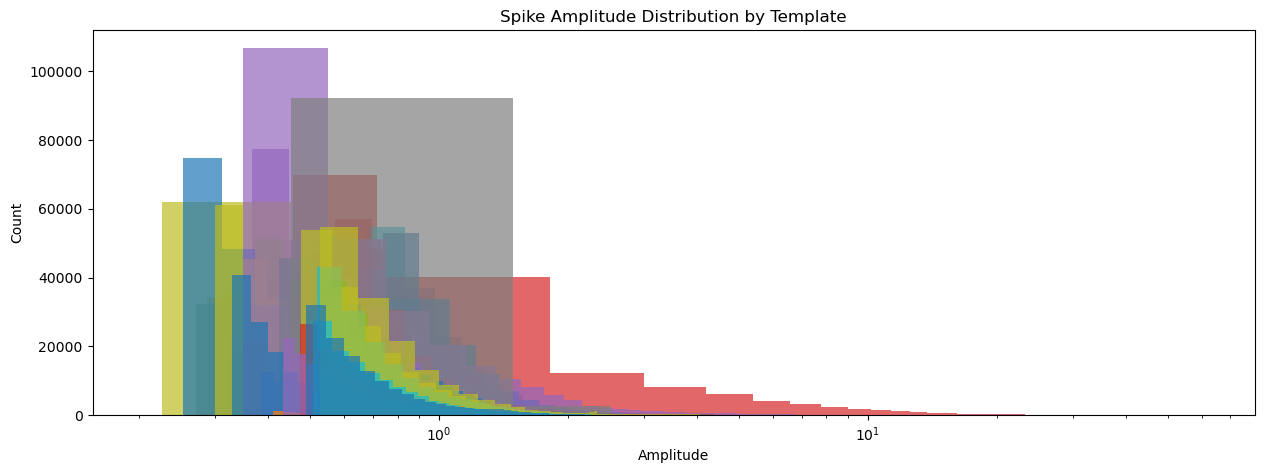

In [13]:
plt.figure(figsize=(15,5))
with h5py.File(hdf5_file, 'r') as f:
    template_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))
    for template in template_names:
        amplitudes = np.array(f['amplitudes'][template])[:, 0]  # Use only the first component
        plt.hist(amplitudes, bins=50, alpha=0.7, label=template)
    
    plt.xscale('log')
    plt.xlabel('Amplitude')
    plt.ylabel('Count')
    plt.title('Spike Amplitude Distribution by Template')
    # plt.legend()
    plt.show()

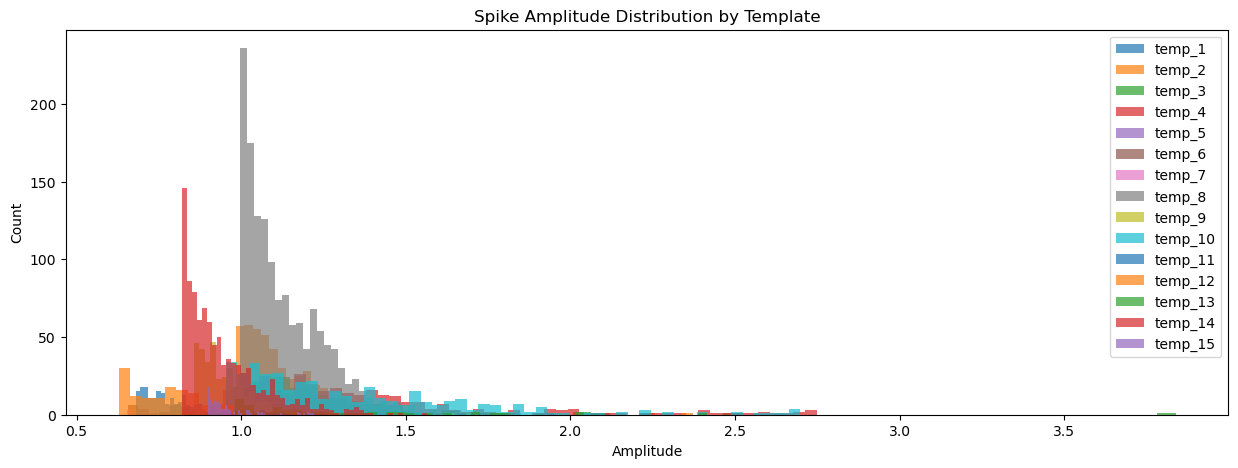

In [188]:
plt.figure(figsize=(15,5))
with h5py.File(hdf5_file, 'r') as f:
    template_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))
    for template in template_names:
        if template == "temp_0":
            continue
        amplitudes = np.array(f['amplitudes'][template])[:, 0]  # Use only the first component
        plt.hist(amplitudes, bins=50, alpha=0.7, label=template)
    plt.xlabel('Amplitude')
    plt.ylabel('Count')
    plt.title('Spike Amplitude Distribution by Template')
    plt.legend()
    plt.show()

In [14]:
plt.figure(figsize=(15,5))
with h5py.File(hdf5_file, 'r') as f:
    template_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))
    for template in template_names:
        # if template == "temp_0":
        #     continue
        amplitudes = np.array(f['amplitudes'][template])[:, 0]  # Use only the first component
        print("Template No: ", template + " samples: ", amplitudes.shape[0])
    #     plt.hist(amplitudes, bins=50, alpha=0.7, label=template)
    # plt.xlabel('Amplitude')
    # plt.ylabel('Count')
    # plt.title('Spike Amplitude Distribution by Template')
    # plt.legend()
    # plt.show()

Template No:  temp_0 samples:  133351
Template No:  temp_1 samples:  26198
Template No:  temp_2 samples:  59107
Template No:  temp_3 samples:  23080
Template No:  temp_4 samples:  4052
Template No:  temp_5 samples:  97517
Template No:  temp_6 samples:  86174
Template No:  temp_7 samples:  134235
Template No:  temp_8 samples:  1073
Template No:  temp_9 samples:  15976
Template No:  temp_10 samples:  221254
Template No:  temp_11 samples:  8546
Template No:  temp_12 samples:  102000
Template No:  temp_13 samples:  110819
Template No:  temp_14 samples:  172624
Template No:  temp_15 samples:  91651
Template No:  temp_16 samples:  8008
Template No:  temp_17 samples:  12359
Template No:  temp_18 samples:  170304
Template No:  temp_19 samples:  163397
Template No:  temp_20 samples:  134556
Template No:  temp_21 samples:  63984
Template No:  temp_22 samples:  4301
Template No:  temp_23 samples:  86010
Template No:  temp_24 samples:  166255
Template No:  temp_25 samples:  20523
Template No:  tem

<Figure size 1500x500 with 0 Axes>

In [15]:
with h5py.File(hdf5_file, 'r') as f:
    print(np.array(f["info"]["duration"]))

[7210]


## Spike Amplitude Distribution (Boxplot)

<Figure size 1500x500 with 0 Axes>

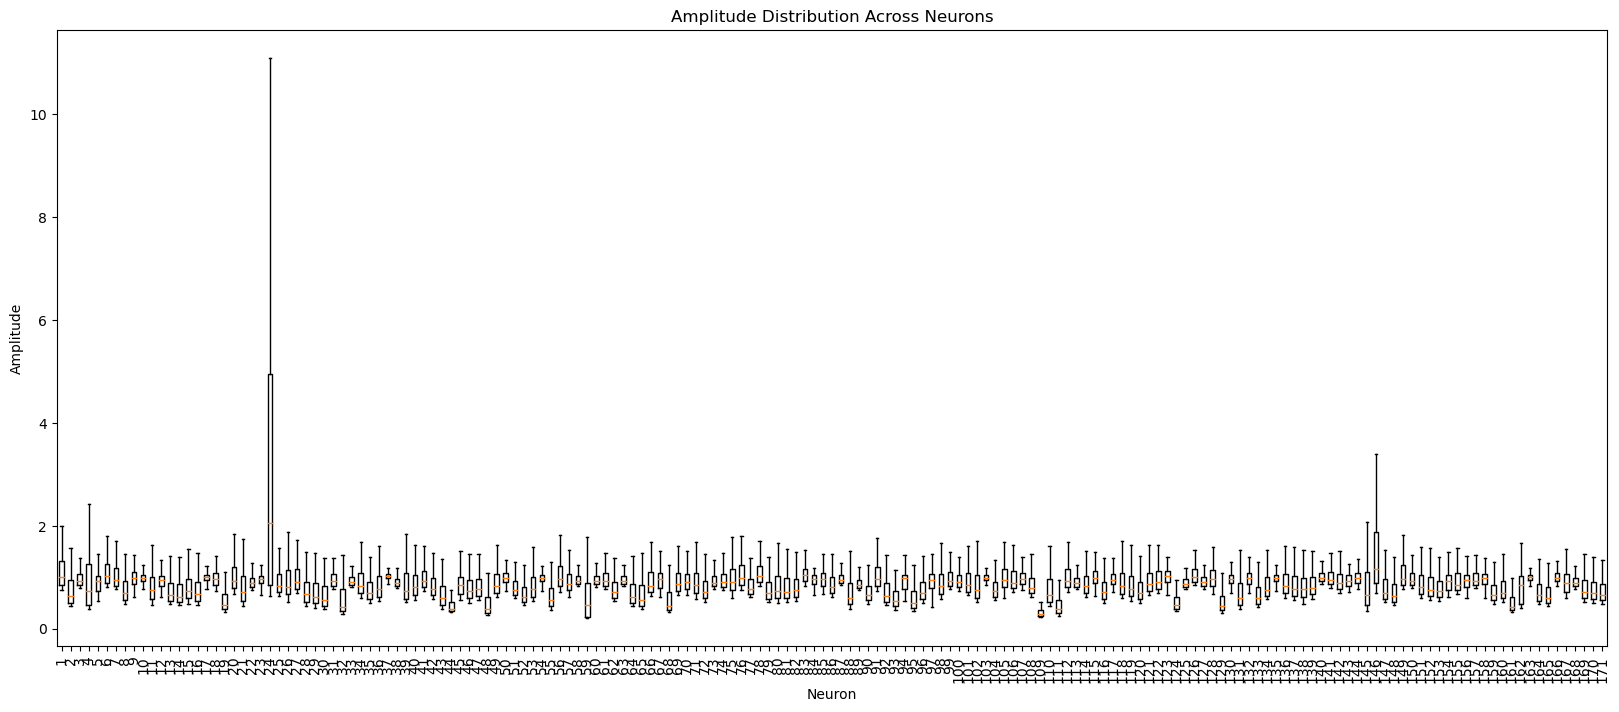

In [16]:
amplitude_data = []

plt.figure(figsize=(15,5))
with h5py.File(hdf5_file, 'r') as f:
    template_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))
    for template in template_names:
        amplitudes = np.array(f['amplitudes'][template])[:, 0]  # Use only the first component
        amplitude_data.append(amplitudes)
        
plt.figure(figsize=(20, 8))
plt.boxplot(amplitude_data, vert=True, showfliers=False)
plt.xticks(rotation=90)
plt.xlabel('Neuron')
plt.ylabel('Amplitude')
plt.title('Amplitude Distribution Across Neurons')
plt.show()


## Fitting CDF to Amplitude Distribution for Each Neuron

In [15]:
# # Open the results.hdf5 file and fit CDFs to the amplitude data
# with h5py.File(hdf5_file, 'r') as f:
#     template_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))

#     # Example: Plot CDFs for a subset of neurons
#     subset_neurons = np.random.choice(template_names, size=10, replace=False)  # Randomly select 10 neurons


#     for template in subset_neurons:
#         # Extract only the first component of amplitudes for the current template
#         amplitudes = np.array(f['amplitudes'][template])[:, 0]

#         # Sort the data for the empirical CDF
#         sorted_amplitudes = np.sort(amplitudes)
#         empirical_cdf = np.arange(1, len(amplitudes) + 1) / len(amplitudes)

#         # Fit a gamma distribution
#         gamma_params = gamma.fit(amplitudes)  # Fits shape, loc, scale
#         gamma_cdf = gamma.cdf(sorted_amplitudes, *gamma_params)

#         # Fit an exponential distribution
#         expon_params = expon.fit(amplitudes)  # Fits loc, scale
#         expon_cdf = expon.cdf(sorted_amplitudes, *expon_params)

#         # # Fit a normal distribution
#         # norm_params = norm.fit(amplitudes)  # Fits mean and standard deviation
#         # norm_cdf = norm.cdf(sorted_amplitudes, *norm_params)

#         # Plot the empirical CDF and fitted CDFs
#         plt.figure(figsize=(4, 3))
#         plt.plot(sorted_amplitudes, empirical_cdf, label='Empirical CDF', color='black', lw=2)
#         plt.plot(sorted_amplitudes, gamma_cdf, label='Fitted Gamma CDF', linestyle='--', color='blue')
#         plt.plot(sorted_amplitudes, expon_cdf, label='Fitted Exponential CDF', linestyle='--', color='red')
#         # plt.plot(sorted_amplitudes, norm_cdf, label='Fitted Normal CDF', linestyle='--', color='green')

#         # Label the plot
#         plt.xlabel('Amplitude')
#         plt.ylabel('CDF')
#         plt.title(f'CDF Fit for {template}')
#         plt.legend()
#         plt.show()




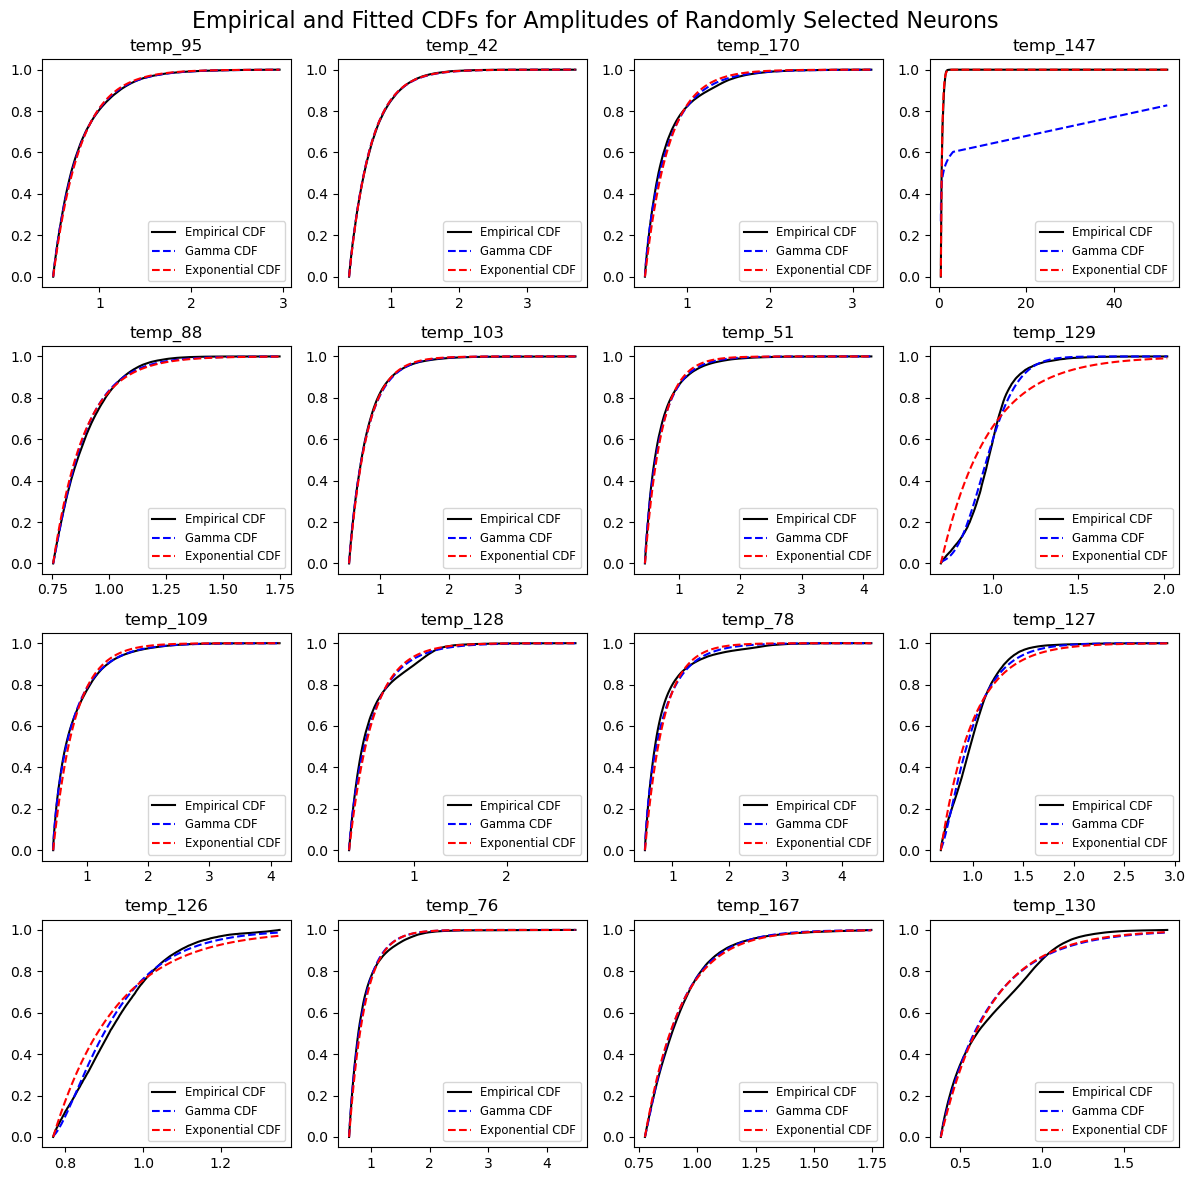

In [14]:
import math

# Open the results.hdf5 file and fit CDFs to the amplitude data
with h5py.File(hdf5_file, 'r') as f:
    template_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))

    selected_neurons = random.sample(template_names, 16)  # Sample 16 neurons for a 4x4 grid

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Empirical and Fitted CDFs for Amplitudes of Randomly Selected Neurons', fontsize=16)
    for i, template in enumerate(selected_neurons):
        ax = axes[math.floor(i / 4), i % 4]
        amplitudes = np.array(f['amplitudes'][template])[:, 0]
        sorted_amplitudes = np.sort(amplitudes)
        empirical_cdf = np.arange(1, len(amplitudes) + 1) / len(amplitudes)

        gamma_params = gamma.fit(amplitudes)
        gamma_cdf = gamma.cdf(sorted_amplitudes, *gamma_params)

        expon_params = expon.fit(amplitudes)
        expon_cdf = expon.cdf(sorted_amplitudes, *expon_params)
        ax.plot(sorted_amplitudes, empirical_cdf, label='Empirical CDF', color='black')
        ax.plot(sorted_amplitudes, gamma_cdf, label='Gamma CDF', linestyle='--', color='blue')
        ax.plot(sorted_amplitudes, expon_cdf, label='Exponential CDF', linestyle='--', color='red')

        ax.set_title(f'{template}')
        ax.legend(loc='lower right', fontsize='small')

    plt.tight_layout()
    plt.show()


## Spike Amplitude Distribution (Histogram) - Separate Plots

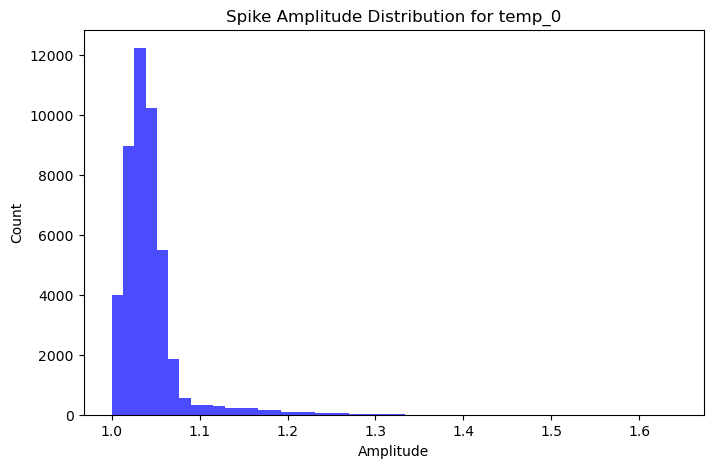

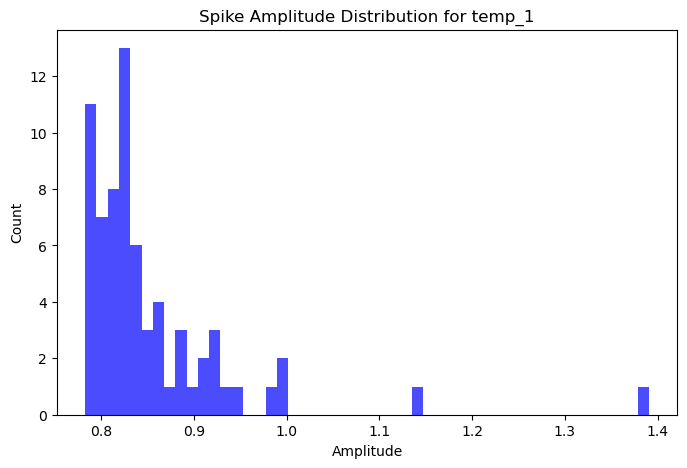

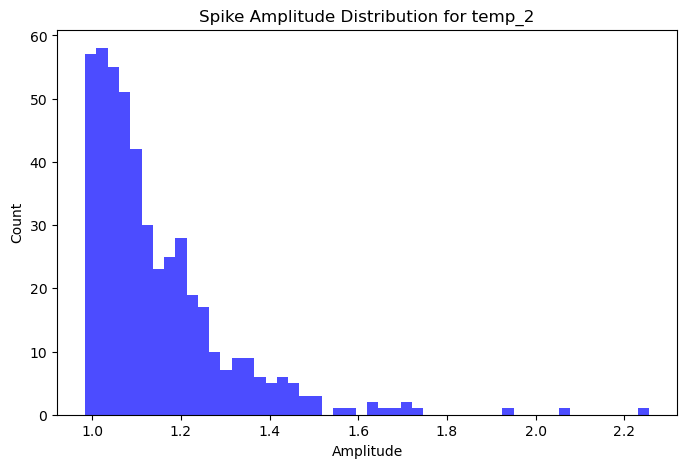

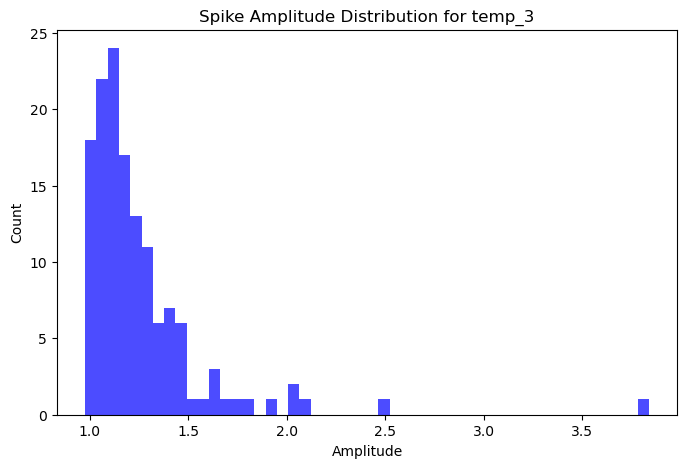

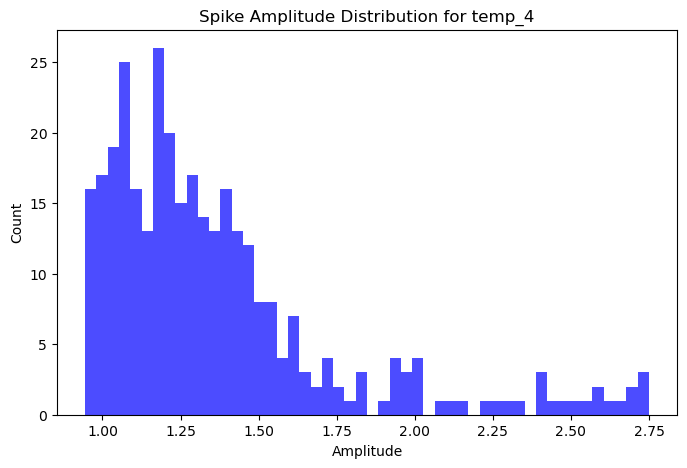

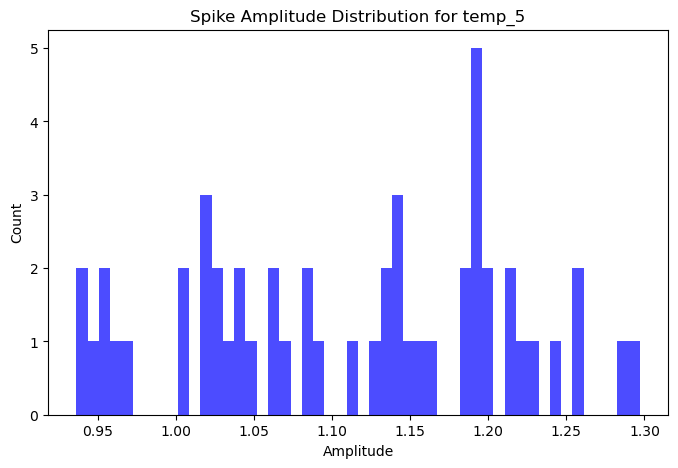

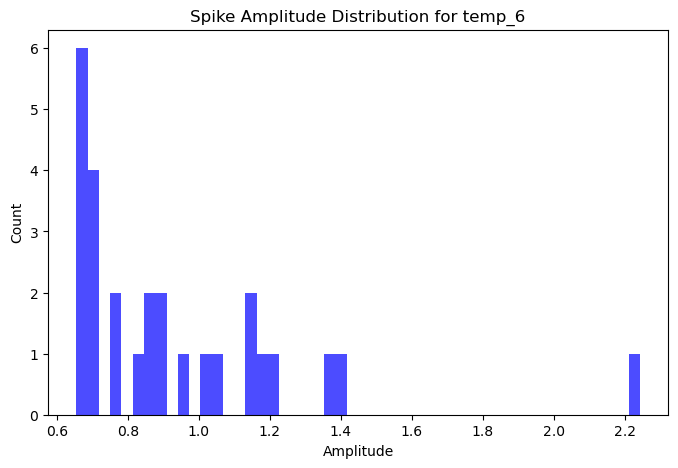

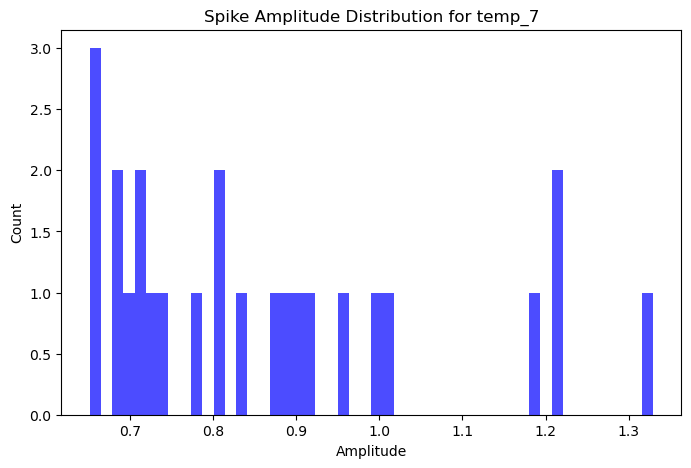

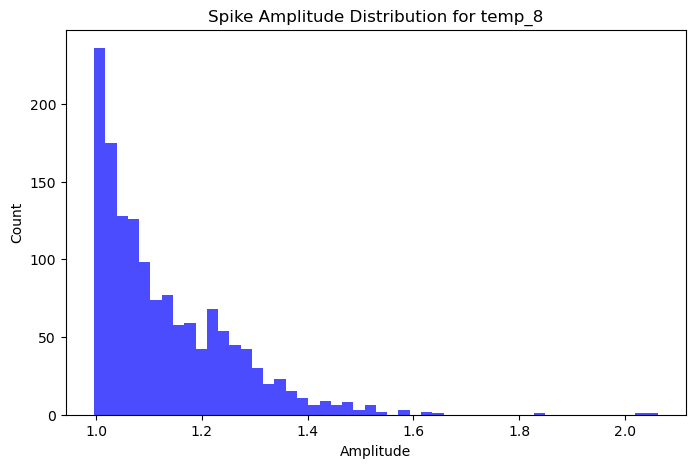

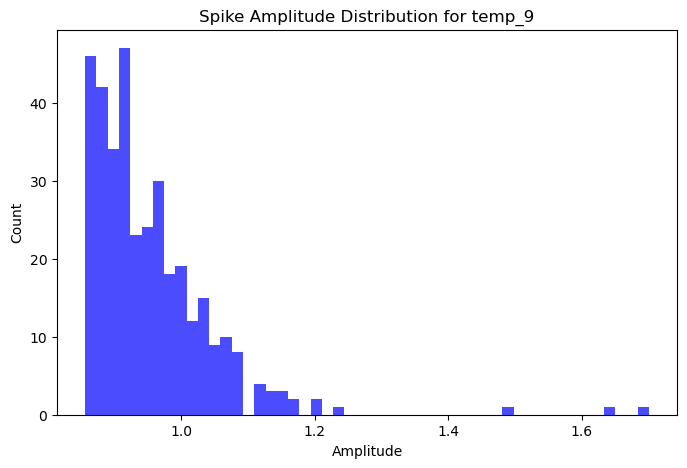

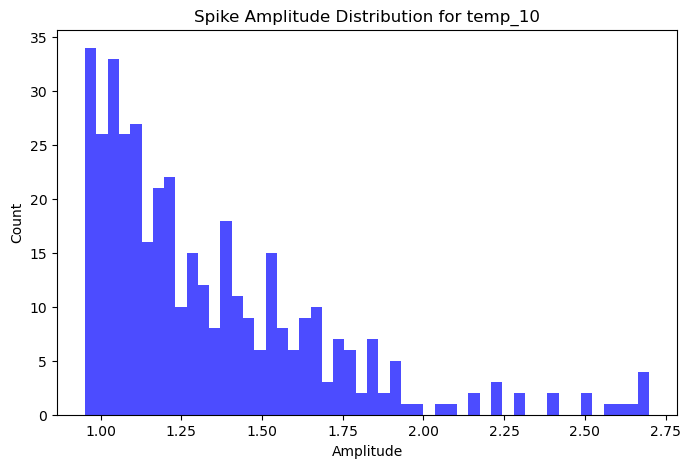

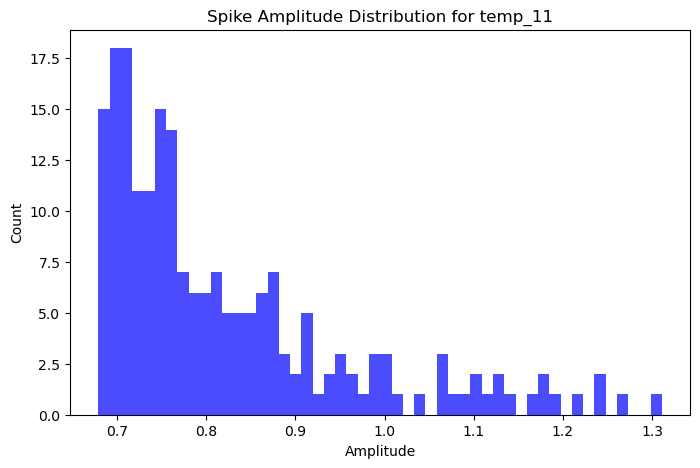

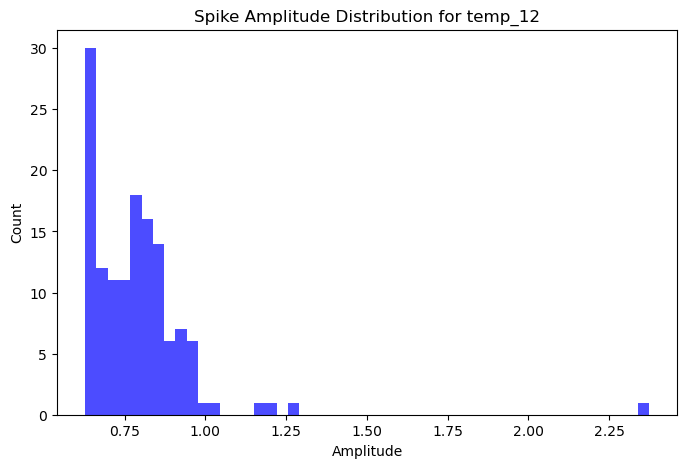

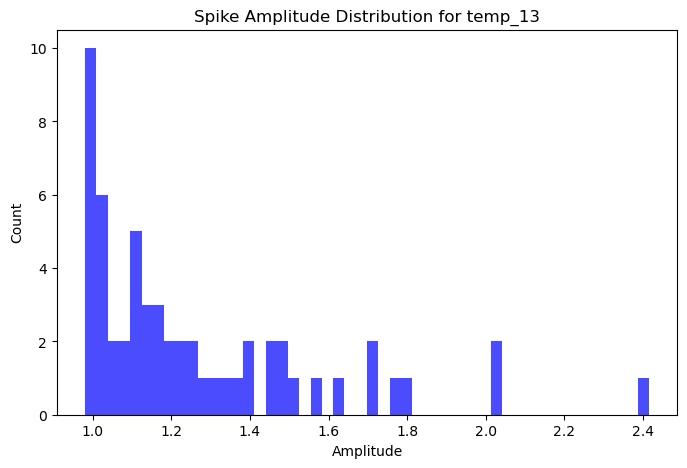

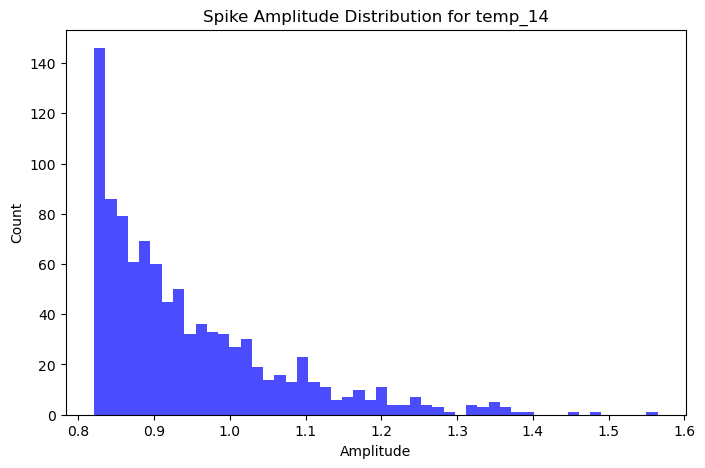

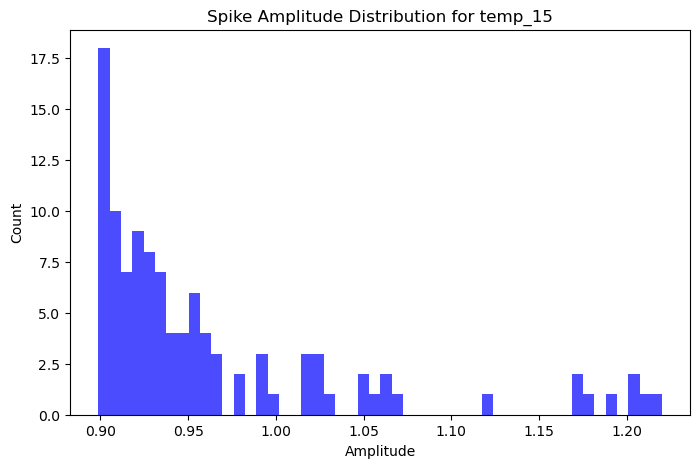

In [190]:
# Open the HDF5 file
with h5py.File(hdf5_file, 'r') as f:
    template_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))
    
    # Loop through each template to create separate histograms
    for template in template_names:
        # Extract only the first component of amplitudes for the current template
        amplitudes = np.array(f['amplitudes'][template])[:, 0]
        
        # Plot the histogram for the current template
        plt.figure(figsize=(8, 5))
        plt.hist(amplitudes, bins=50, color='blue', alpha=0.7)
        
        # Label the plot
        plt.xlabel('Amplitude')
        plt.ylabel('Count')
        plt.title(f'Spike Amplitude Distribution for {template}')
        
        # Display the plot
        plt.show()

## Inter-Spike Interval Histogram

['amplitudes', 'info', 'spiketimes']


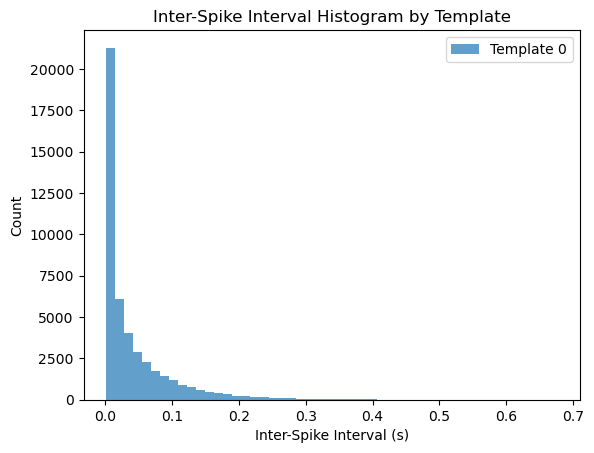

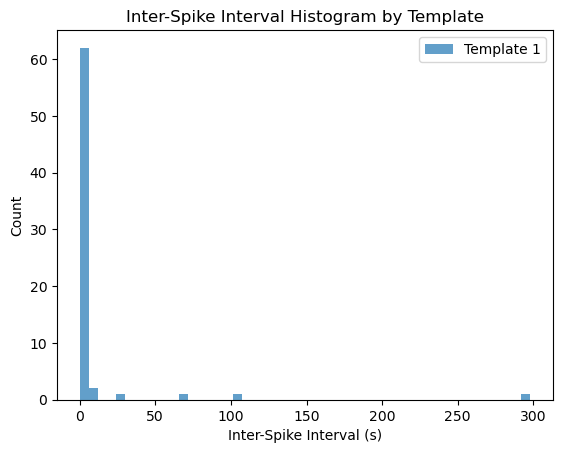

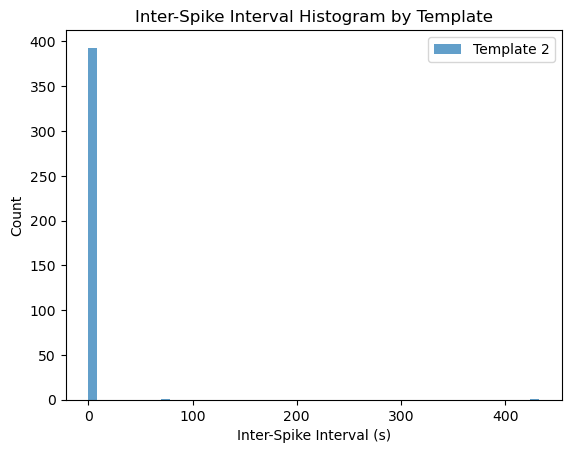

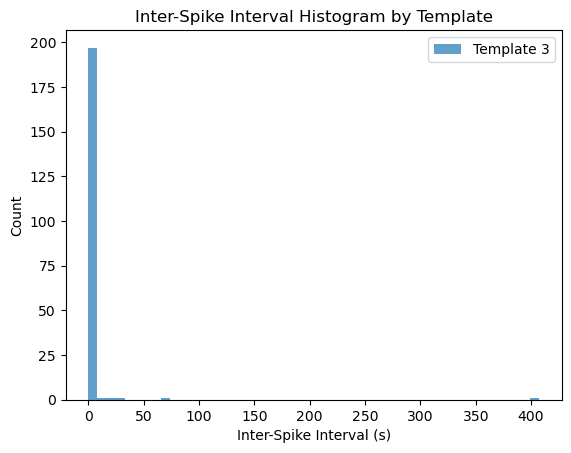

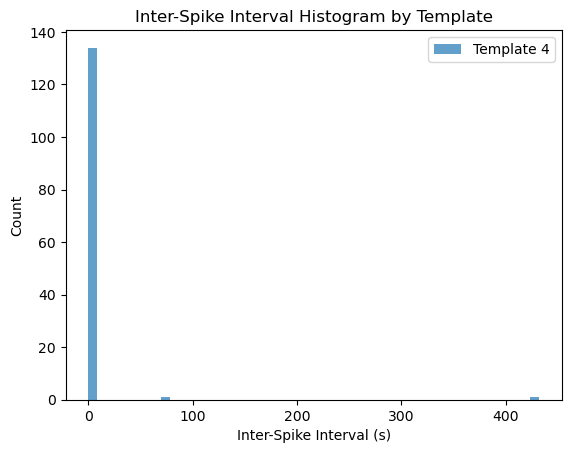

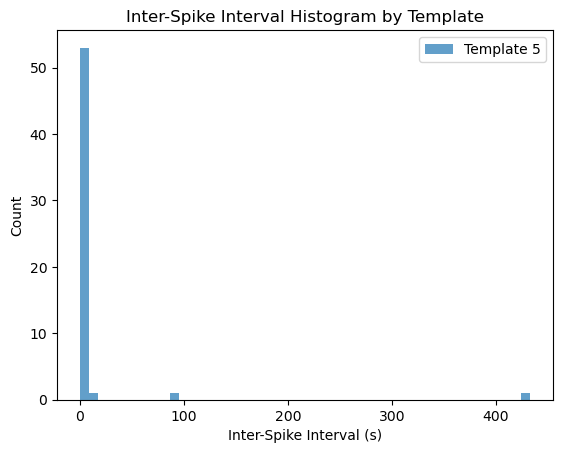

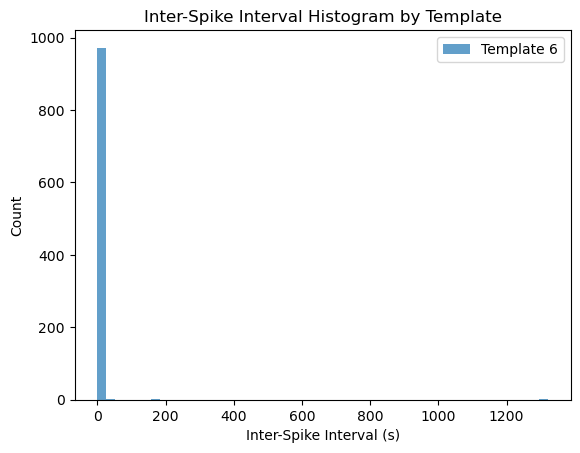

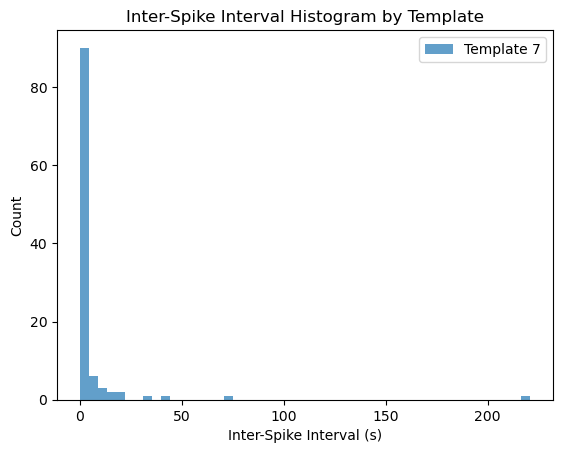

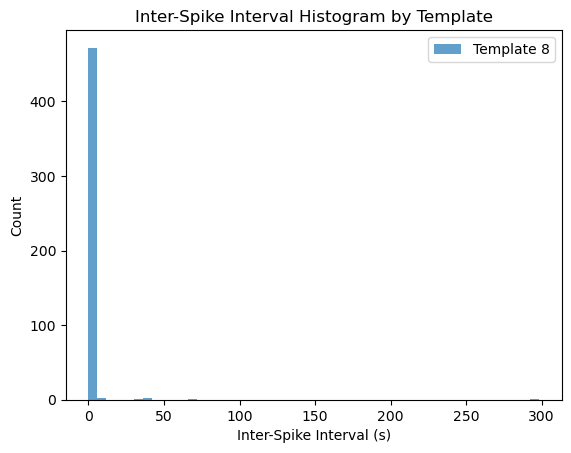

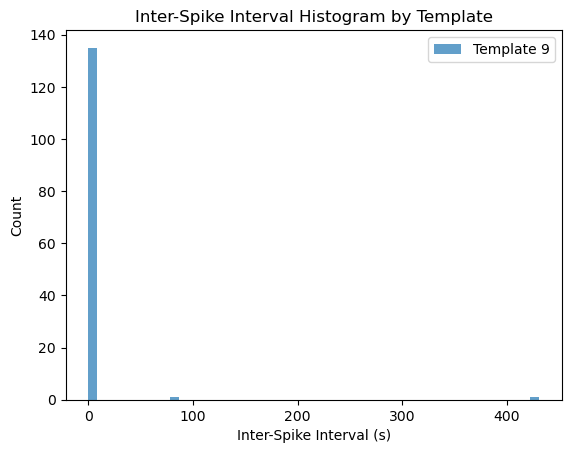

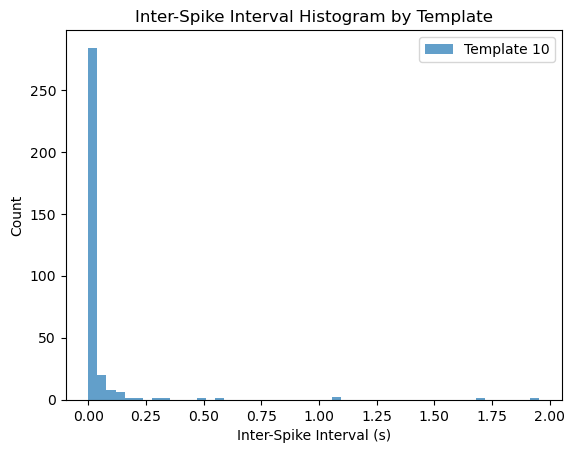

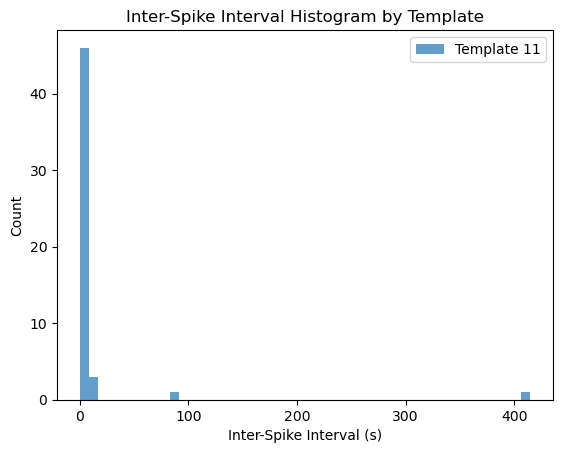

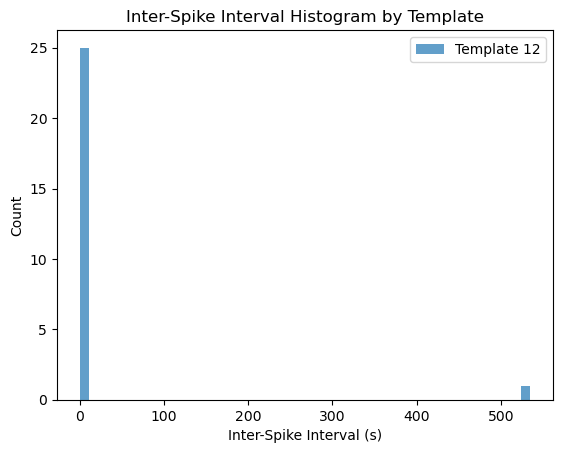

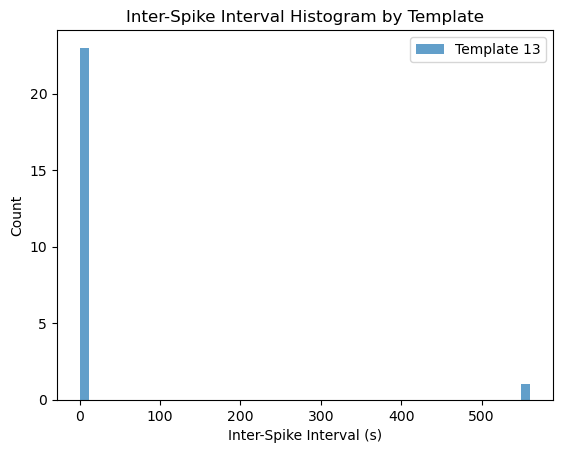

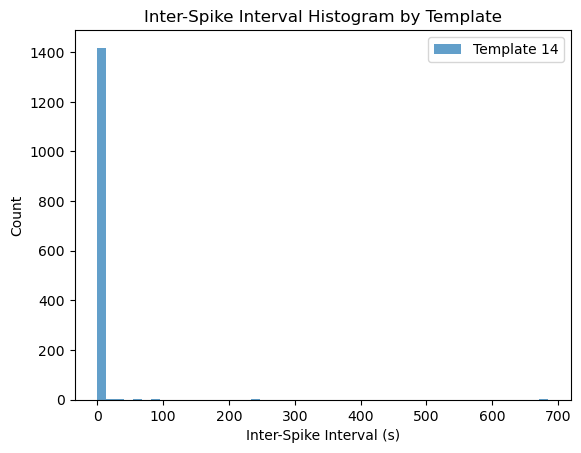

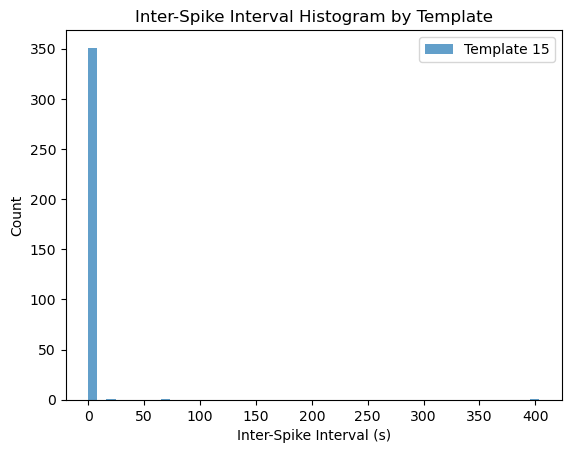

In [191]:
# Open the HDF5 file
with h5py.File(hdf5_file, 'r') as f:
    # Find the spike times datasets for each template
    # print(f)
    print(list(f.keys()))
    # print(np.array(f['spiketimes']["temp_0"]))
    spiketimes_group = f['spiketimes']  # Group containing spike times for each template
    template_names = list(spiketimes_group.keys())  # List of template names (e.g., 'temp_0', 'temp_1', ...)

    # Prepare the data for plotting
    spike_data = []
    for template in template_names:
        spike_times = np.array(spiketimes_group[template]) / sampling_rate # Extract spike times for this template
        spike_data.append(spike_times)
    
    for i, spike_times in enumerate(spike_data):
        isis = np.diff(spike_times)  # Calculate intervals
        plt.hist(isis, bins=50, alpha=0.7, label=f'Template {i}')
        plt.xlabel('Inter-Spike Interval (s)')
        plt.ylabel('Count')
        plt.title('Inter-Spike Interval Histogram by Template')
        plt.legend()
        plt.show()

## Fitting CDF to ISI Distribution for Each Neuron

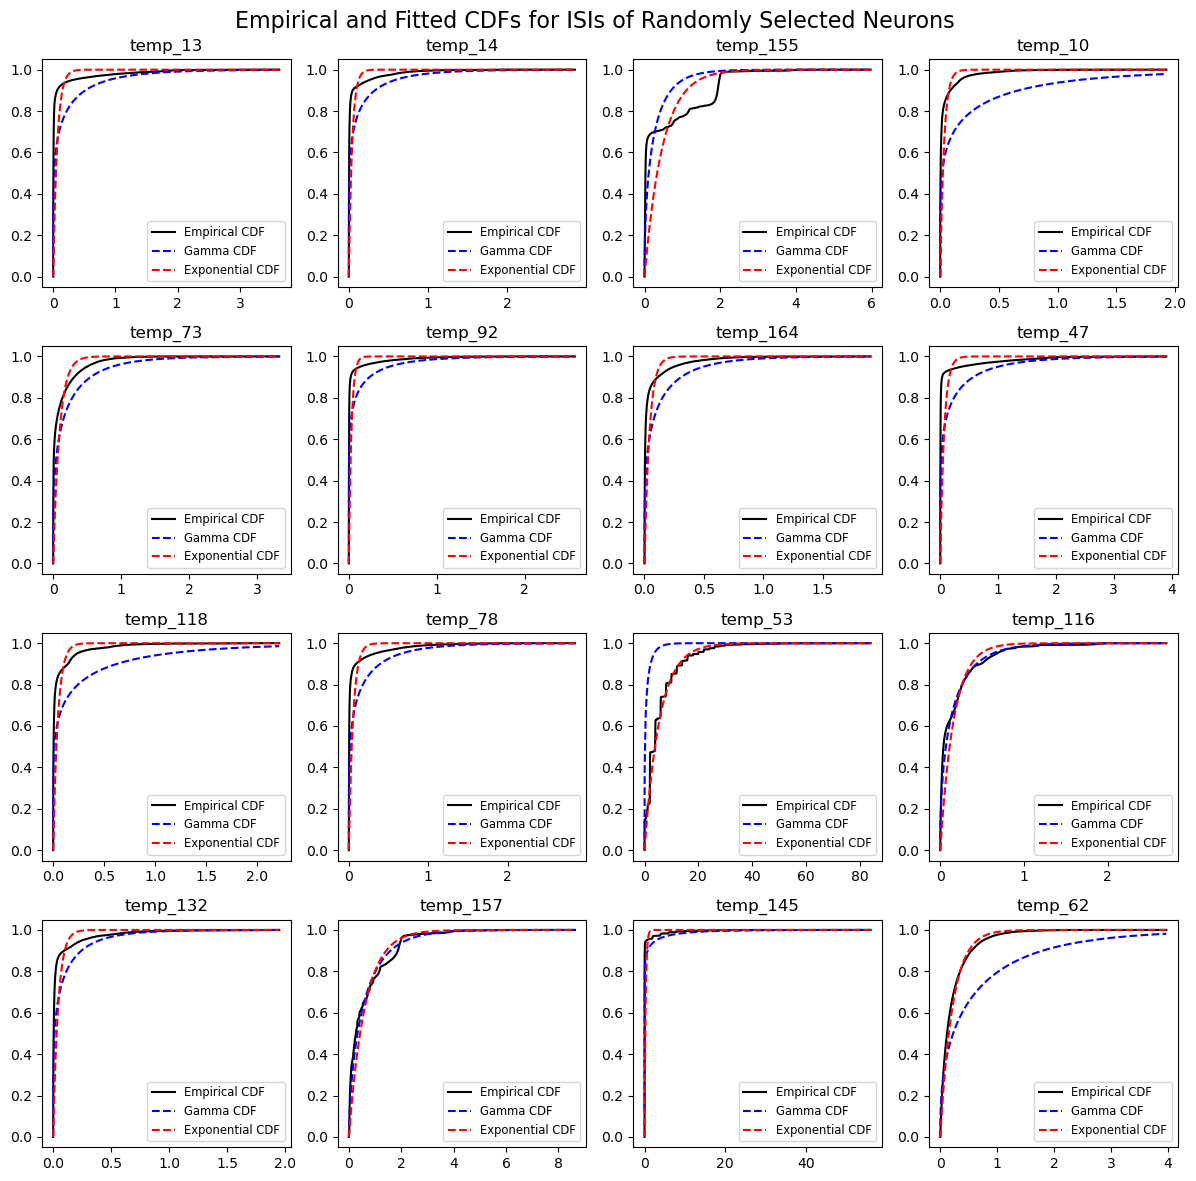

In [11]:
with h5py.File(hdf5_file, 'r') as f:
    template_names = sorted(f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))

    # Randomly select 16 neurons for the grid display
    selected_neurons = random.sample(template_names, 16)  # Sample 16 neurons for a 4x4 grid

    # Set up a 4x4 grid of subplots
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Empirical and Fitted CDFs for ISIs of Randomly Selected Neurons', fontsize=16)
    for i, template in enumerate(selected_neurons):
        ax = axes[math.floor(i / 4), i % 4]

        # Get the spike times for the current neuron and compute ISIs
        spike_times = np.array(f['spiketimes'][template]) / 30000  # Convert to seconds
        if len(spike_times) > 1:
            isis = np.diff(spike_times)  # Calculate inter-spike intervals

            # Sort ISIs for the empirical CDF
            sorted_isis = np.sort(isis)
            empirical_cdf = np.arange(1, len(isis) + 1) / len(isis)

            # Fit a gamma distribution
            gamma_params = gamma.fit(isis)
            gamma_cdf = gamma.cdf(sorted_isis, *gamma_params)

            # Fit an exponential distribution
            expon_params = expon.fit(isis)
            expon_cdf = expon.cdf(sorted_isis, *expon_params)

            # Plot the empirical CDF and fitted CDFs
            ax.plot(sorted_isis, empirical_cdf, label='Empirical CDF', color='black')
            ax.plot(sorted_isis, gamma_cdf, label='Gamma CDF', linestyle='--', color='blue')
            ax.plot(sorted_isis, expon_cdf, label='Exponential CDF', linestyle='--', color='red')

        # Add title and legend for each subplot
        ax.set_title(f'{template}')
        ax.legend(loc='lower right', fontsize='small')

    # Adjust layout for the grid
    plt.tight_layout()
    plt.show()


## Spike Amplitude vs. Time Scatter Plot

['amplitudes', 'info', 'spiketimes']


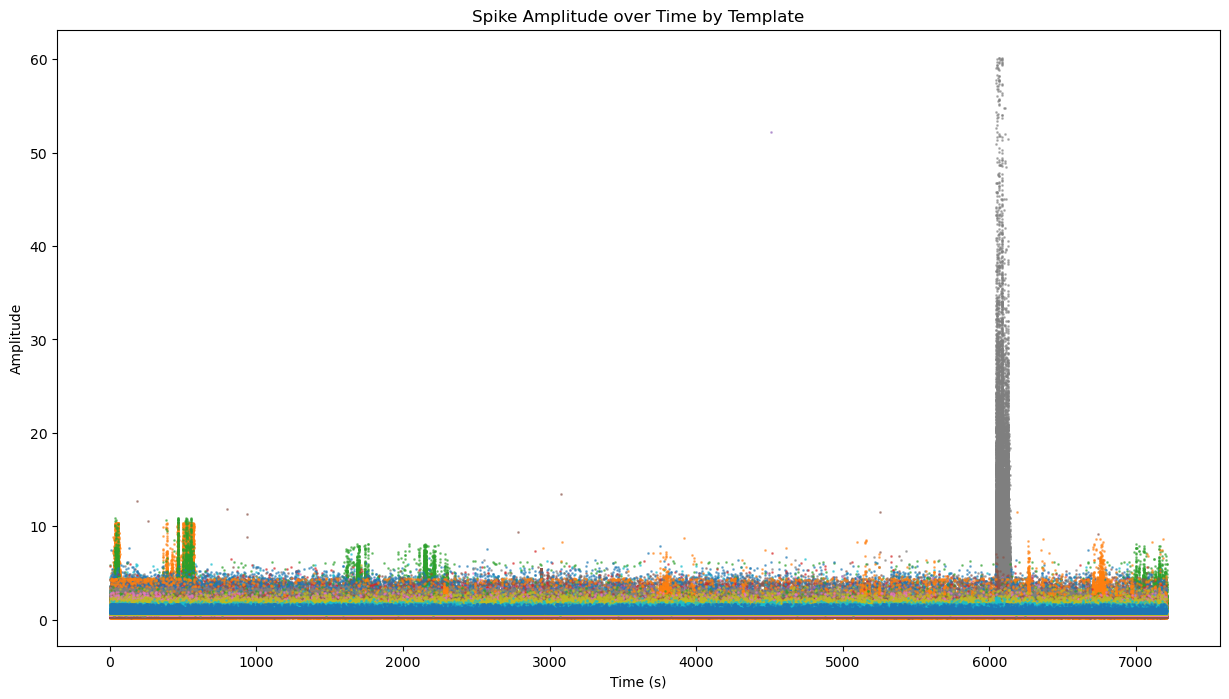

In [19]:
# Open the HDF5 file
with h5py.File(hdf5_file, 'r') as f:
    # Find the spike times datasets for each template
    
    print(list(f.keys()))
    
    spiketimes_group = f['spiketimes']  # Group containing spike times for each template
    template_names = list(spiketimes_group.keys())  # List of template names (e.g., 'temp_0', 'temp_1', ...)
    plt.figure(figsize=(15,8))
    for template in template_names:
        # if template == "temp_0":
        #     continue
        spike_times = np.array(spiketimes_group[template]) / sampling_rate
        amplitudes = np.array(f['amplitudes'][template])[:, 0]
        plt.scatter(spike_times, amplitudes, alpha=0.5, s=1, label=template)

    # plt.yscale('log')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Spike Amplitude over Time by Template')
    # plt.legend()
    plt.show()

## Spike Count Per Neuron

['amplitudes', 'info', 'spiketimes']


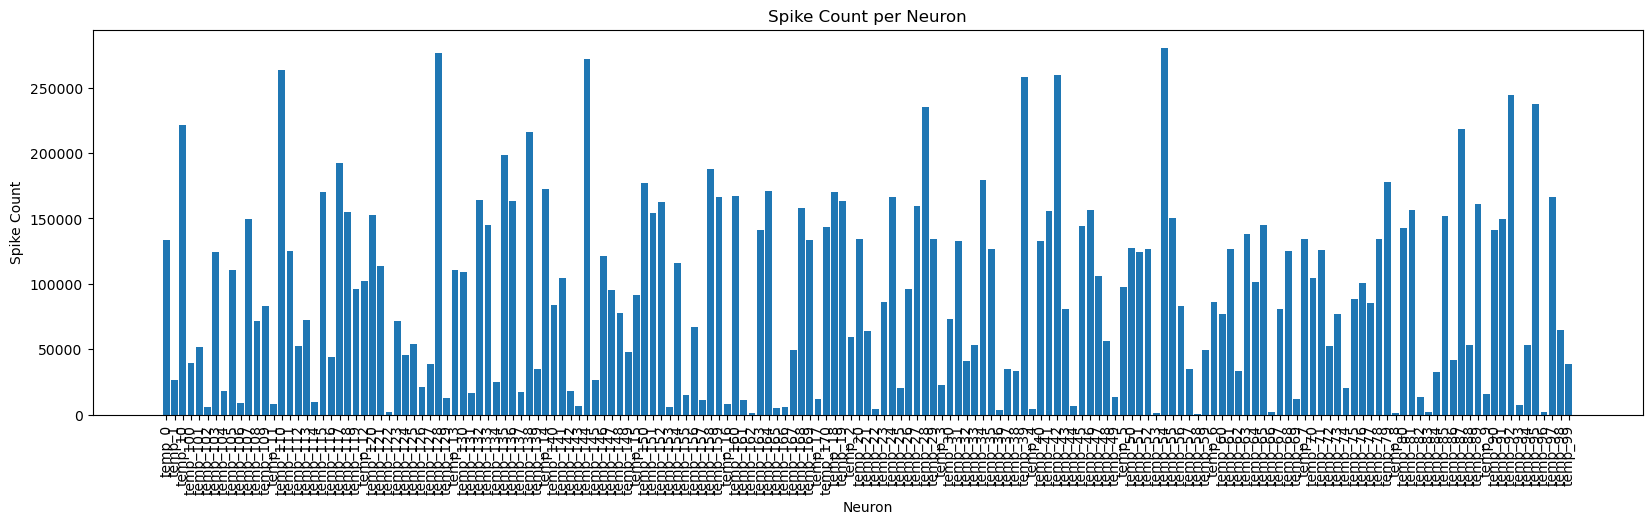

In [16]:
with h5py.File(hdf5_file, 'r') as f:
    # Find the spike times datasets for each template
    
    print(list(f.keys()))
    
    spiketimes_group = f['spiketimes']  # Group containing spike times for each template
    template_names = list(spiketimes_group.keys())  # List of template names (e.g., 'temp_0', 'temp_1', ...)

    # Prepare the data for plotting
    spike_data = []
    for template in template_names:
        spike_times = np.array(spiketimes_group[template]) / sampling_rate # Extract spike times for this template
        spike_data.append(spike_times)

    spike_counts = [len(spike_data[i]) for i in range(len(template_names))]
    plt.figure(figsize=(20,5))
    plt.bar(template_names, spike_counts)
    plt.xticks(rotation=90)
    plt.xlabel('Neuron')
    plt.ylabel('Spike Count')
    plt.title('Spike Count per Neuron')
    plt.show()


## Distribution of Mean Firing Rate Across Neurons

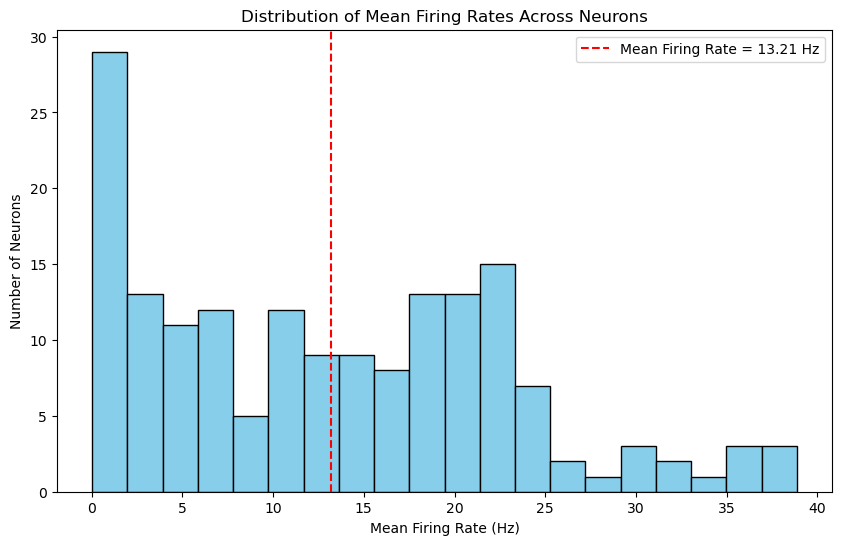

In [17]:
firing_rates = []
with h5py.File(hdf5_file, 'r') as f:
    neurons = sorted(f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))
    
    for neuron in neurons:
        # Get spike times for the neuron and convert to seconds
        spike_times = np.array(f['spiketimes'][neuron]) / 30000  # Assuming a 30 kHz sampling rate

        if spike_times.size > 0:
            # Calculate the duration from the first to the last spike time
            # duration = spike_times[-1] - spike_times[0]
            # Calculate firing rate as (number of spikes / duration in seconds)
            firing_rate = len(spike_times) / 7210
            firing_rates.append(firing_rate)
        else:
            # If no spikes, firing rate is zero
            firing_rates.append(0)

# Plot the histogram of mean firing rates across neuron
plt.figure(figsize=(10, 6))
plt.hist(firing_rates, bins=20, color='skyblue', edgecolor='black')
# plt.xscale('log')
plt.xlabel('Mean Firing Rate (Hz)')
plt.ylabel('Number of Neurons')
plt.title('Distribution of Mean Firing Rates Across Neurons')

mean_firing_rate = np.mean(firing_rates)
plt.axvline(mean_firing_rate, color='red', linestyle='--', linewidth=1.5, label=f'Mean Firing Rate = {mean_firing_rate:.2f} Hz')
plt.legend()

plt.show()

# Mua.HDF5

In [23]:
# Path
hdf5_file = r"C:\Users\Ribhav\Desktop\UIUC\Classes\Git Repos\Work\MIV_Results\Data\skim449_RC_9_19_24\continuous.mua.hdf5"

## Spike Time Distribution

### Raster Plot

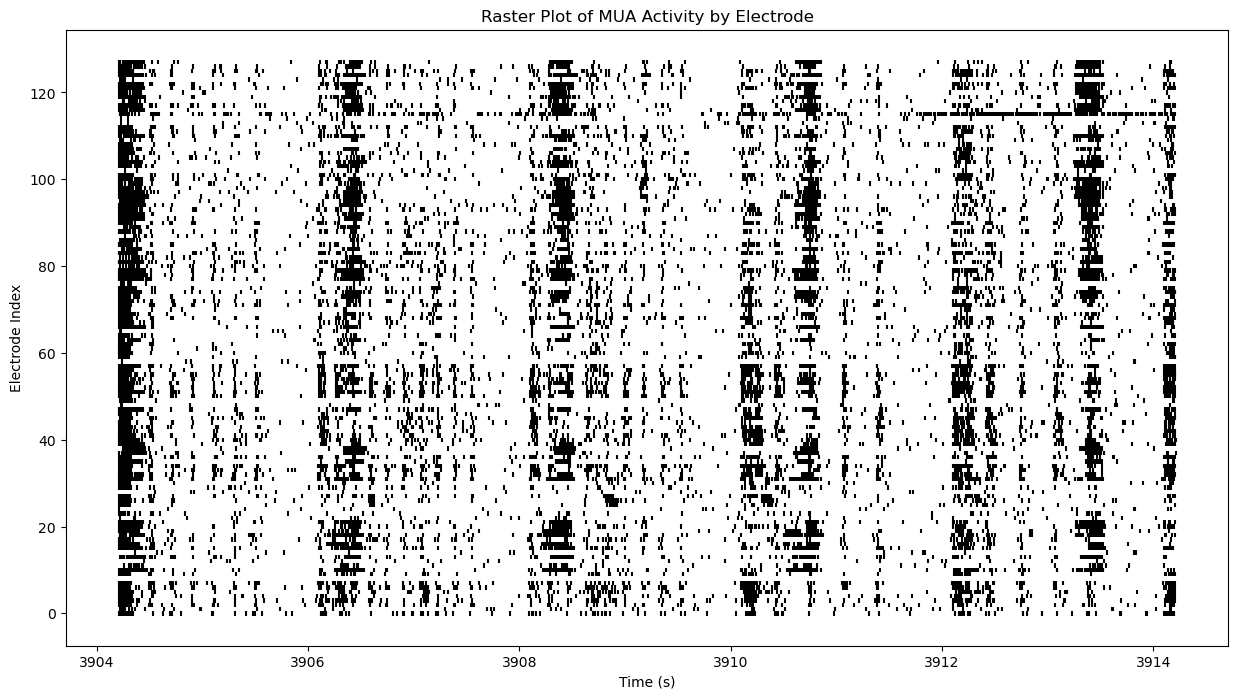

In [26]:
start_time = 3904.20996666
end_time = 3914.20996666

spike_data = []
with h5py.File(hdf5_file, 'r') as f:
    electrode_names = sorted(f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))
    for electrode in electrode_names:
        spike_times = np.array(f['spiketimes'][electrode]) / sampling_rate  # Convert to seconds

        mask = (spike_times >= start_time) & (spike_times <= end_time)
        filtered_spike_times = spike_times[mask]        

        spike_data.append(filtered_spike_times)

plt.figure(figsize=(15, 8))
plt.eventplot(spike_data, colors='black')
plt.xlabel('Time (s)')
plt.ylabel('Electrode Index')
plt.title('Raster Plot of MUA Activity by Electrode')
plt.show()


### Boxplot

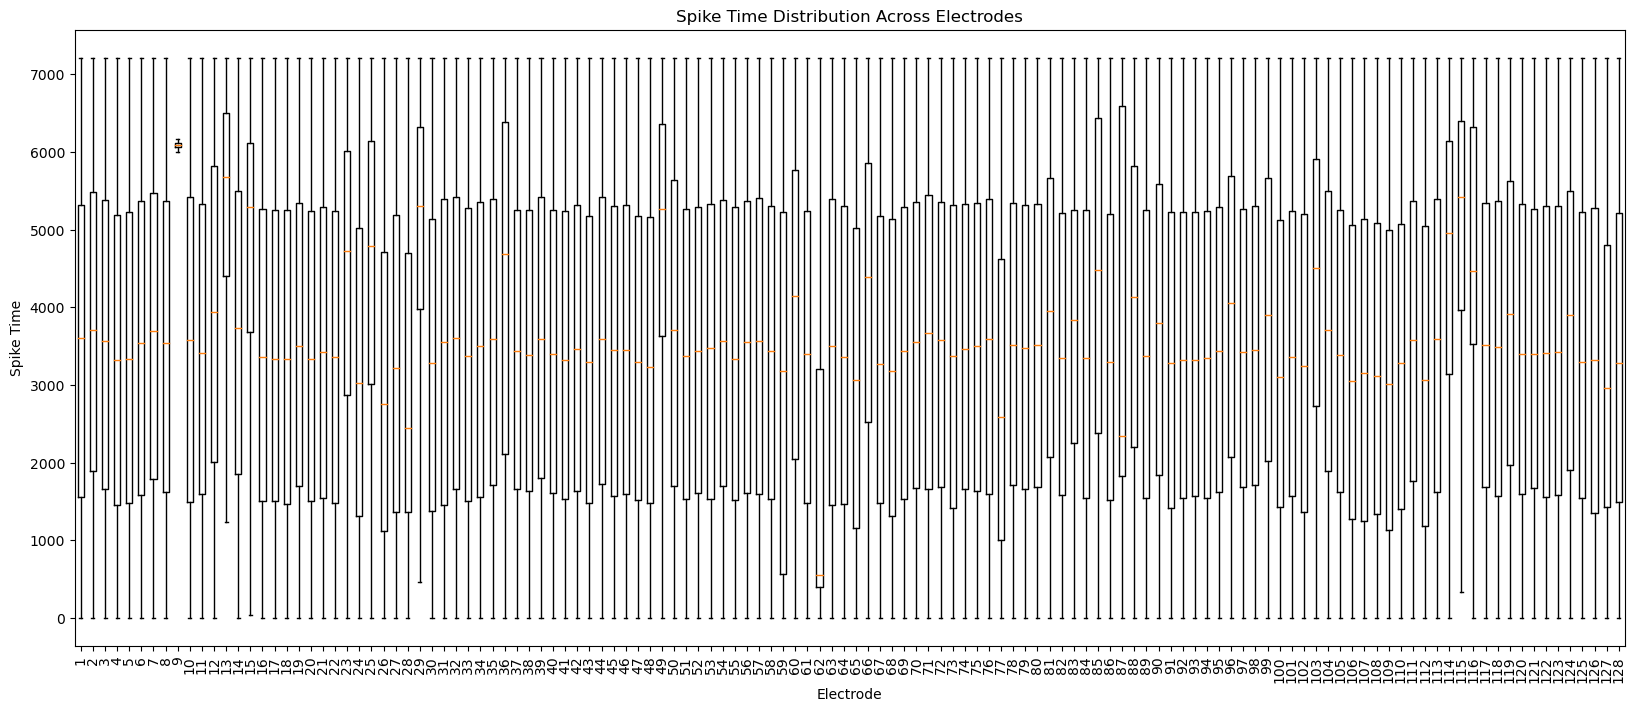

In [27]:
spike_data = []

with h5py.File(hdf5_file, 'r') as f:
    electrode_names = sorted(f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))
    for electrode in electrode_names:
        spike_times = np.array(f['spiketimes'][electrode]) / sampling_rate  # Convert to seconds
        spike_data.append(spike_times)

plt.figure(figsize=(20, 8))
plt.boxplot(spike_data, vert=True, showfliers=False)
plt.xticks(rotation=90)
plt.xlabel('Electrode')
plt.ylabel('Spike Time')
plt.title('Spike Time Distribution Across Electrodes')
plt.show()


## Amplitude Distribution Histogram by Electrode

### Histograms

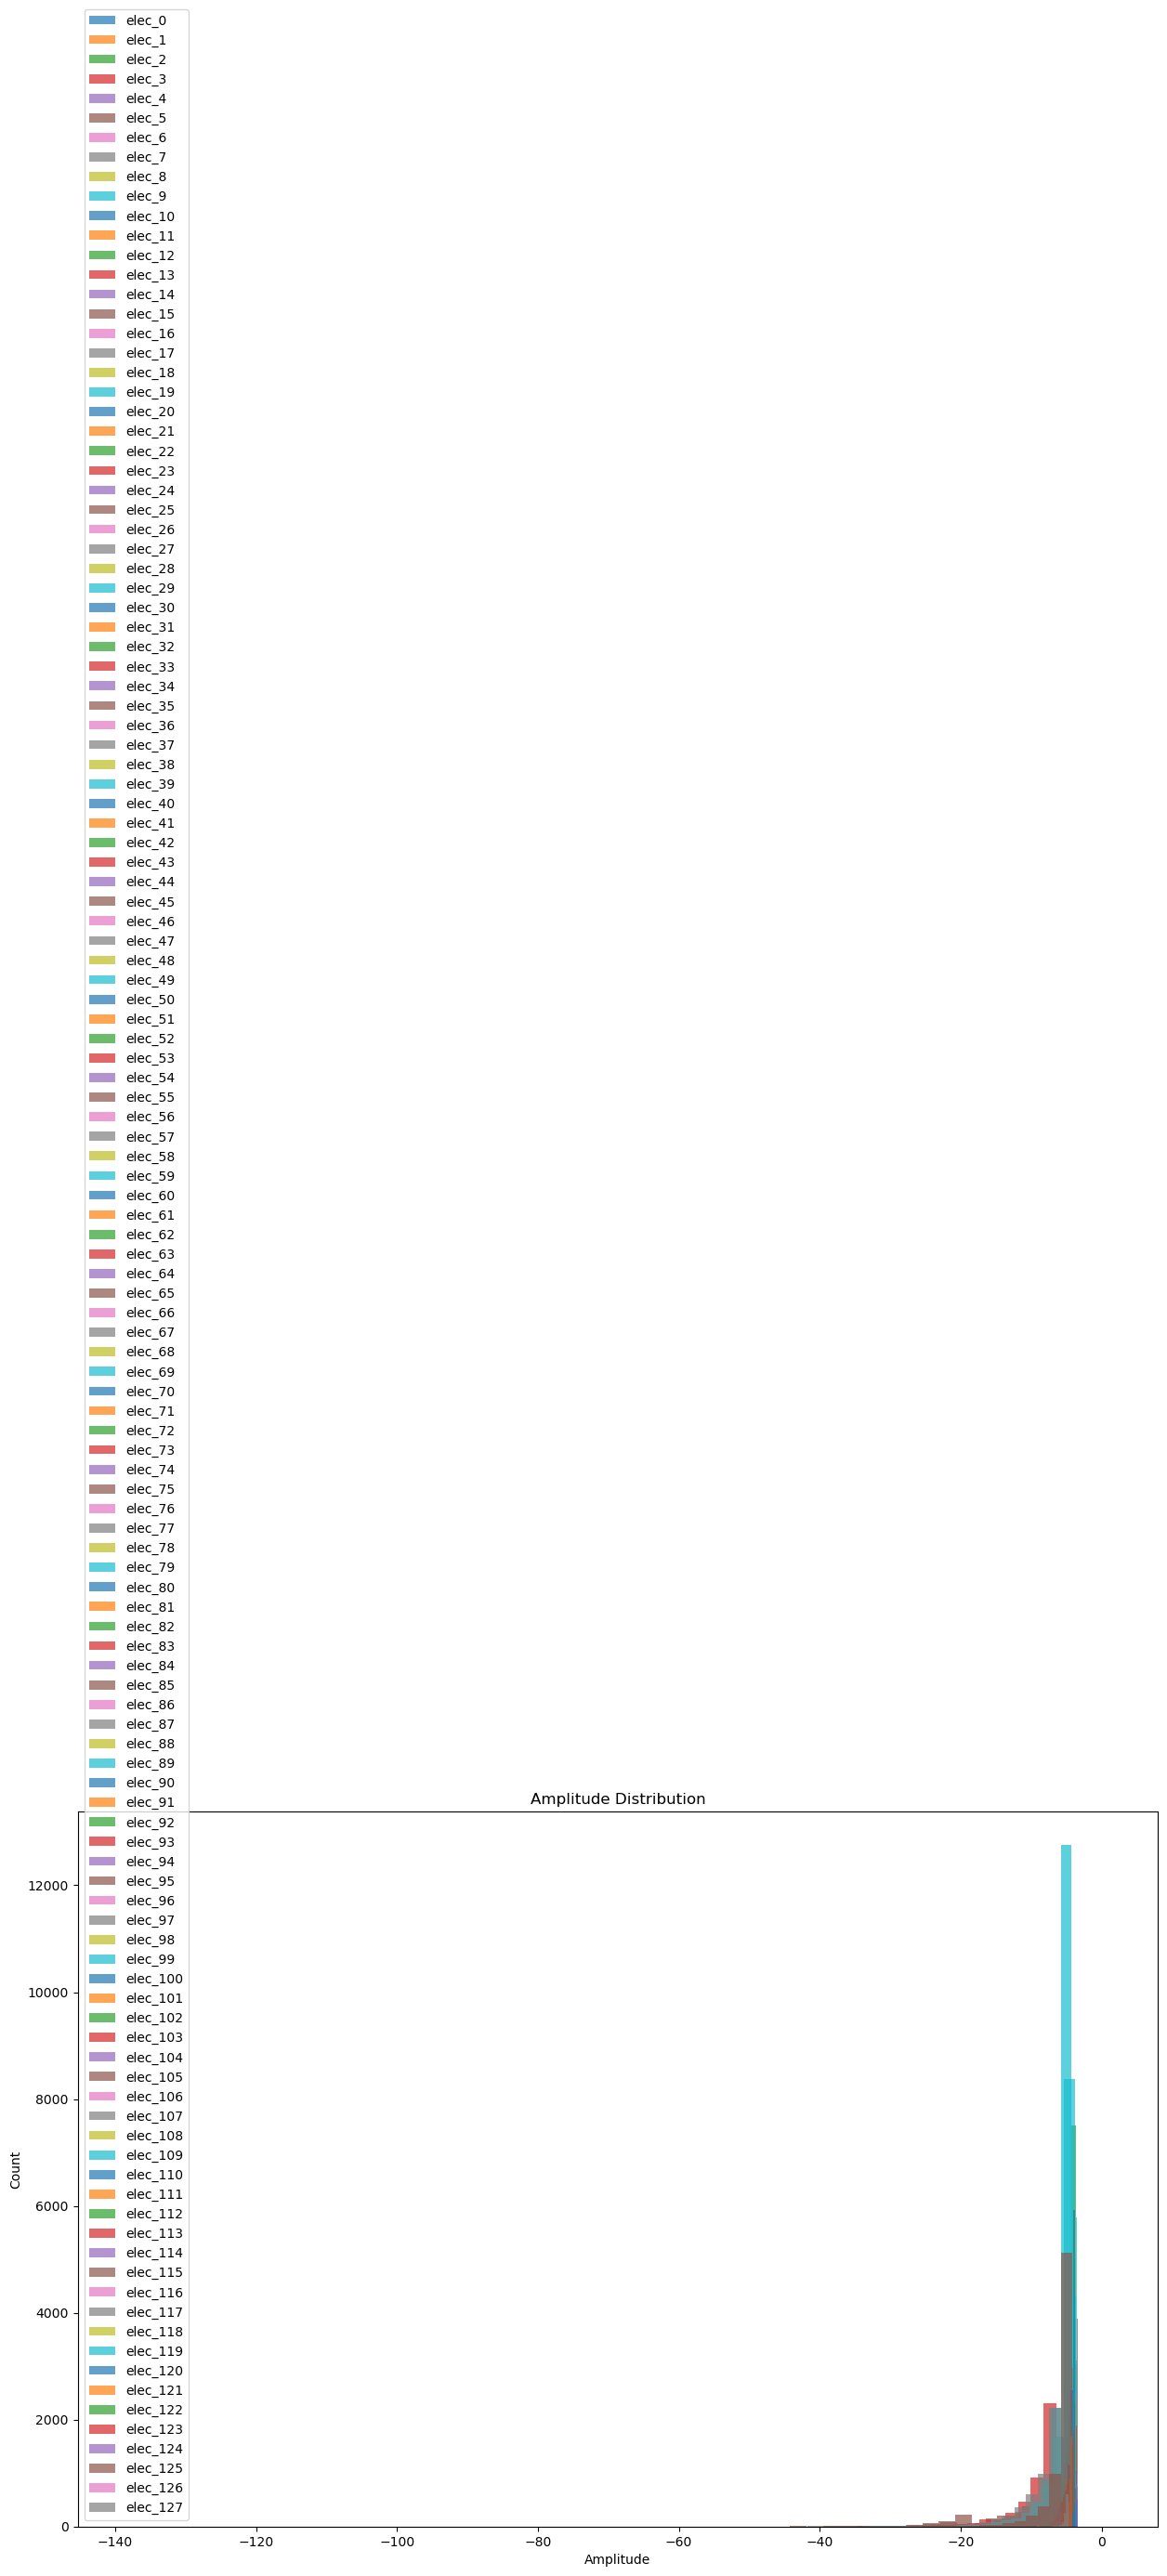

In [197]:
plt.figure(figsize=(15, 10))
with h5py.File(hdf5_file, 'r') as f:
    for electrode in electrode_names:
        amplitudes = np.array(f['amplitudes'][electrode])
        # plt.figure(figsize=(8, 5))
        plt.hist(amplitudes, bins=50, alpha=0.7, label=electrode)
    plt.legend()
    plt.xlabel('Amplitude')
    plt.ylabel('Count')
    plt.title('Amplitude Distribution')
    plt.show()


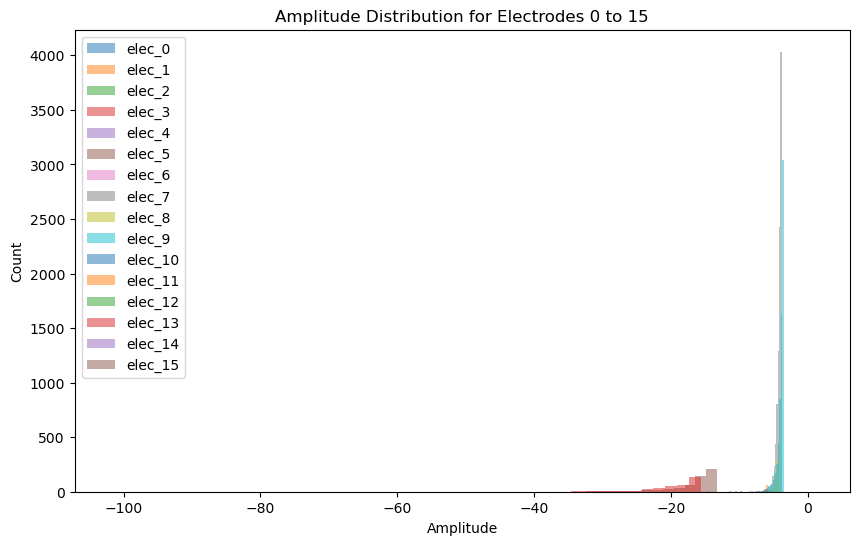

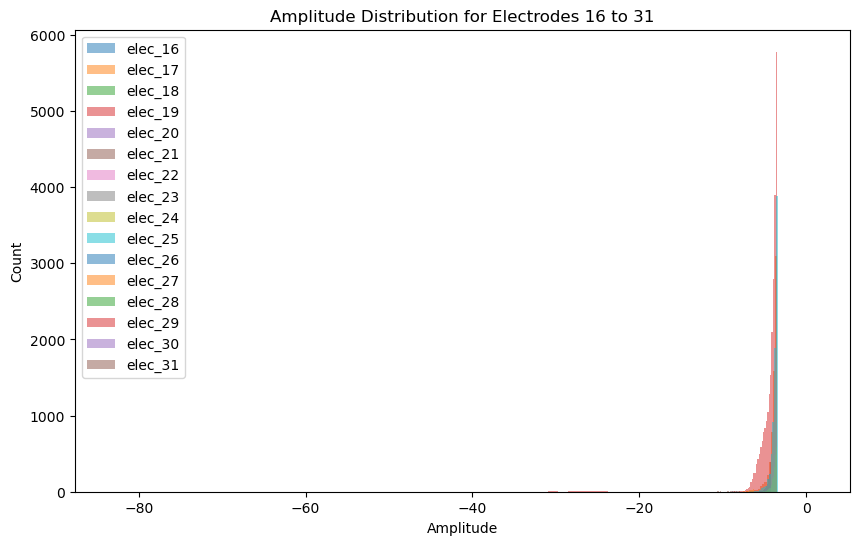

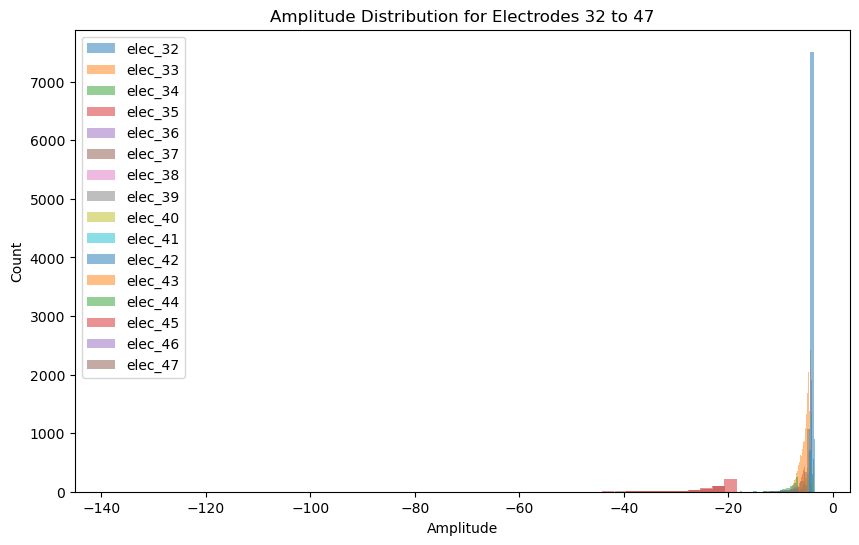

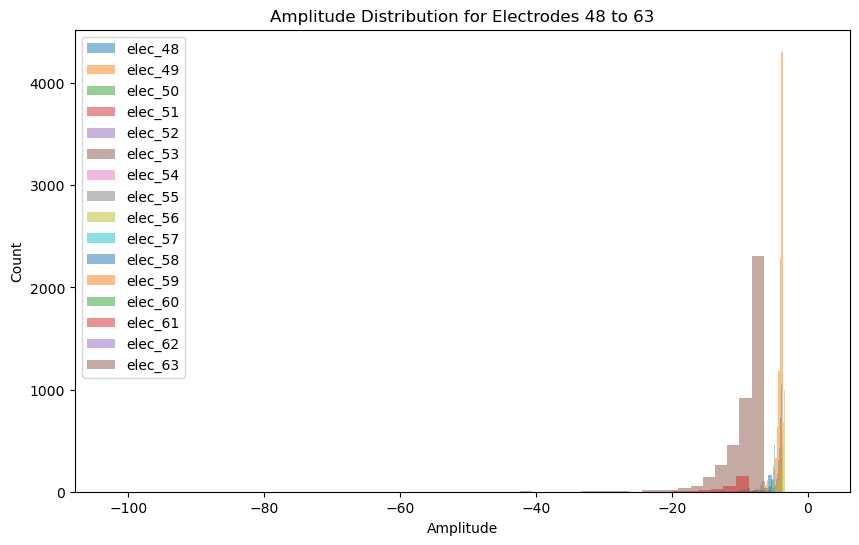

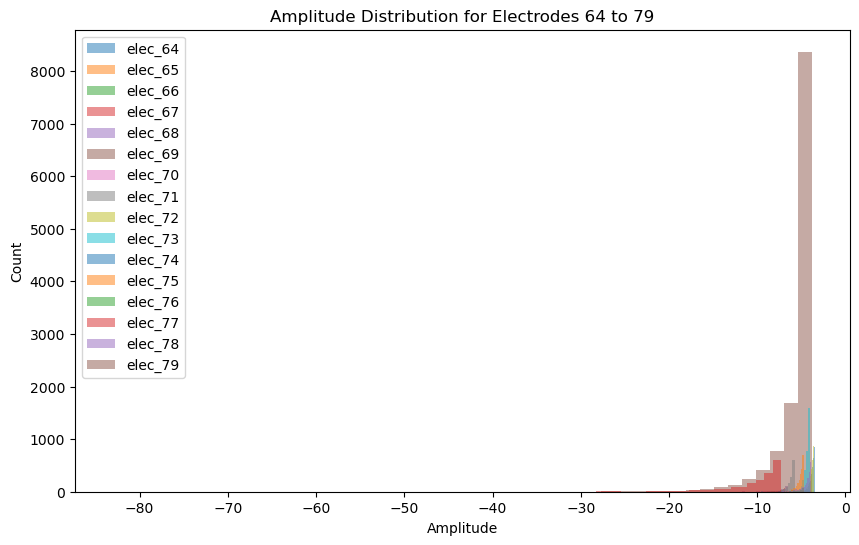

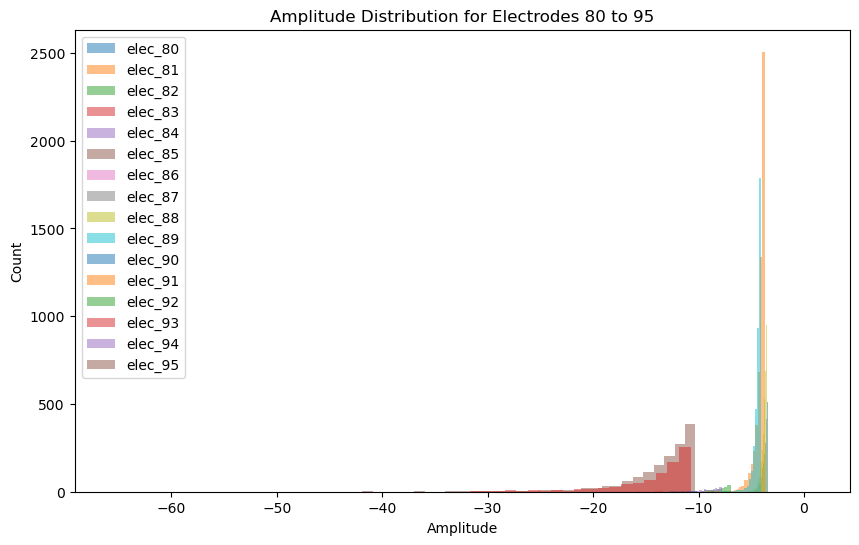

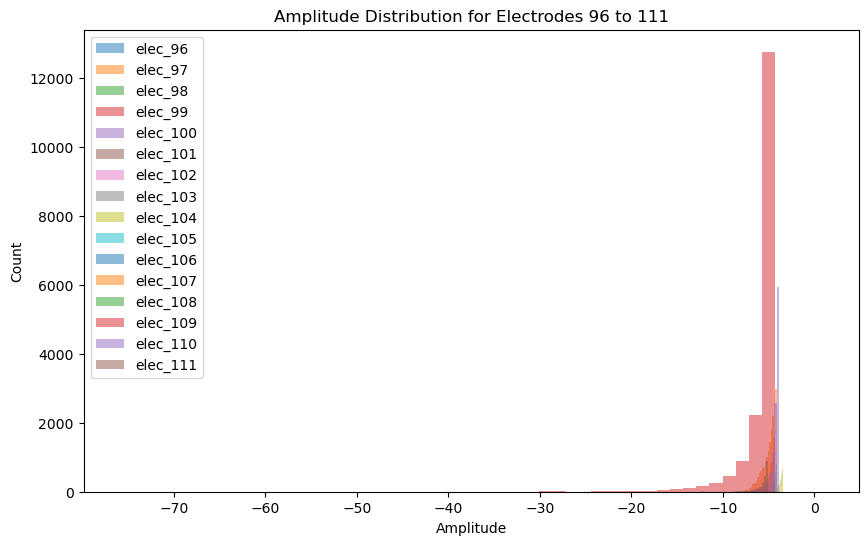

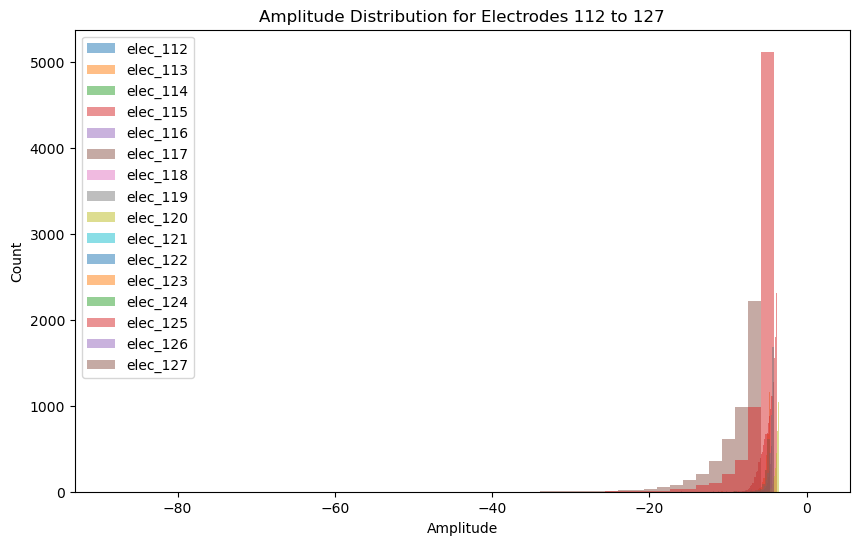

In [198]:
group_size = 16  # Number of electrodes per group plot

with h5py.File(hdf5_file, 'r') as f:
    electrode_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))

    for group_start in range(0, len(electrode_names), group_size):
        plt.figure(figsize=(10, 6))
        for electrode in electrode_names[group_start:group_start + group_size]:
            amplitudes = np.array(f['amplitudes'][electrode])
            # plt.hist(amplitudes, bins=50, alpha=0.5, label=electrode, histtype='step')
            plt.hist(amplitudes, bins=50, alpha=0.5, label=electrode)
        plt.xlabel('Amplitude')
        plt.ylabel('Count')
        plt.title(f'Amplitude Distribution for Electrodes {group_start} to {group_start + group_size - 1}')
        plt.legend()
        plt.show()

### Boxplot

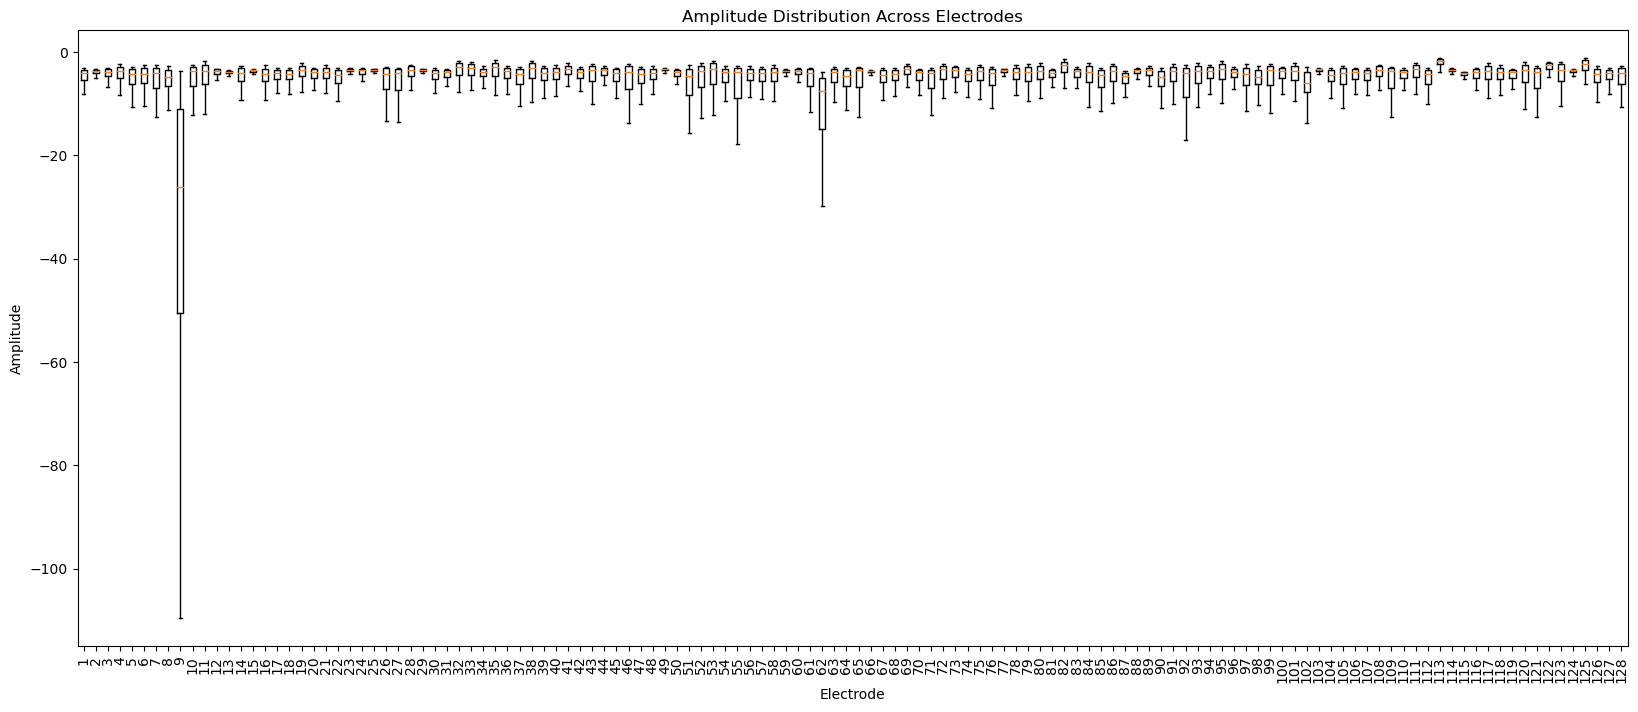

In [28]:
amplitude_data = []

with h5py.File(hdf5_file, 'r') as f:
    electrode_names = sorted(f['amplitudes'].keys(), key=lambda x: int(x.split('_')[1]))
    for electrode in electrode_names:
        amplitudes = np.array(f['amplitudes'][electrode])
        amplitude_data.append(amplitudes)

plt.figure(figsize=(20, 8))
plt.boxplot(amplitude_data, vert=True, showfliers=False)
plt.xticks(rotation=90)
plt.xlabel('Electrode')
plt.ylabel('Amplitude')
plt.title('Amplitude Distribution Across Electrodes')
plt.show()


## Firing Rates

In [30]:
with h5py.File(hdf5_file, 'r') as f:
    print(np.array(f["info"]["duration"]))

[7210]


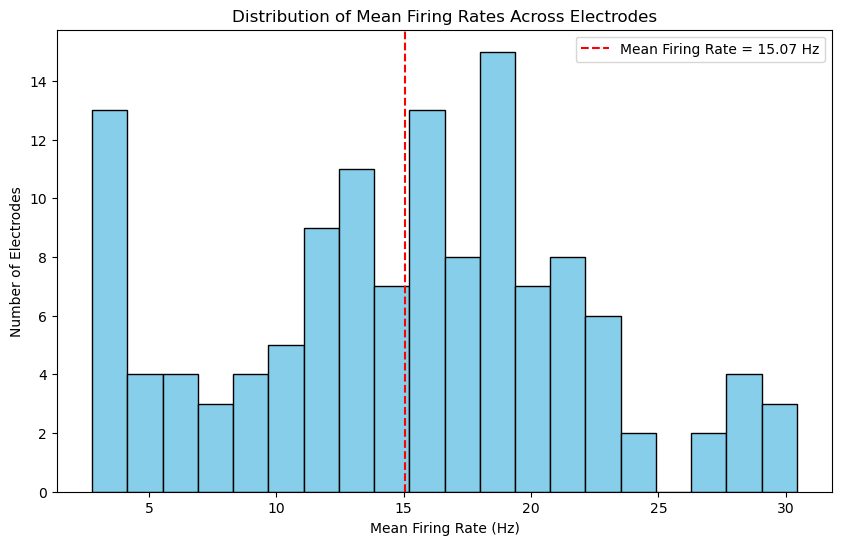

In [39]:
firing_rates = []
with h5py.File(hdf5_file, 'r') as f:
    electrodes = sorted(f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))
    
    for electrode in electrodes:
        # Get spike times for the electrode and convert to seconds
        spike_times = np.array(f['spiketimes'][electrode]) / 30000  # Assuming a 30 kHz sampling rate

        if spike_times.size > 0:
            # Calculate the duration from the first to the last spike time
            duration = spike_times[-1] - spike_times[0]
            # Calculate firing rate as (number of spikes / duration in seconds)
            firing_rate = len(spike_times) / 7210
            firing_rates.append(firing_rate)
        else:
            # If no spikes, firing rate is zero
            firing_rates.append(0)

# Plot the histogram of mean firing rates across electrodes
plt.figure(figsize=(10, 6))
plt.hist(firing_rates, bins=20, color='skyblue', edgecolor='black')
# plt.xscale('log')
plt.xlabel('Mean Firing Rate (Hz)')
plt.ylabel('Number of Electrodes')
plt.title('Distribution of Mean Firing Rates Across Electrodes')

mean_firing_rate = np.mean(firing_rates)
plt.axvline(mean_firing_rate, color='red', linestyle='--', linewidth=1.5, label=f'Mean Firing Rate = {mean_firing_rate:.2f} Hz')
plt.legend()

plt.show()

# Mapping

In [200]:
hdf5_results = r"C:\Users\Ribhav\Desktop\UIUC\Classes\Git Repos\Work\MIV_Results\continuous.result.hdf5"
hdf5_mua = r"C:\Users\Ribhav\Desktop\UIUC\Classes\Git Repos\Work\MIV_Results\continuous.mua.hdf5"

In [201]:
import h5py
import numpy as np

def find_closest_electrode(spike_times, electrode_spike_times):
    # Skip if electrode_spike_times is empty
    if electrode_spike_times.size == 0:
        return 0
    # Calculate a similarity score based on close timings
    return np.sum([np.min(np.abs(electrode_spike_times - t)) < 0.001 for t in spike_times])

# Mapping dictionary
neuron_to_electrode_map = {}

# Load both files
with h5py.File(hdf5_results, 'r') as results_f, h5py.File(hdf5_mua, 'r') as mua_f:
    templates = sorted(results_f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))
    electrodes = sorted(mua_f['spiketimes'].keys(), key=lambda x: int(x.split('_')[1]))

    for template in templates:
        neuron_spike_times = np.array(results_f['spiketimes'][template]) / 30000  # Convert to seconds
        
        # Track the best match electrode
        best_match, best_score = None, 0
        for electrode in electrodes:
            electrode_spike_times = np.array(mua_f['spiketimes'][electrode]) / 30000
            score = find_closest_electrode(neuron_spike_times, electrode_spike_times)
            if score > best_score:
                best_score = score
                best_match = electrode

        neuron_to_electrode_map[template] = best_match
        print(f'{template} is most likely detected by {best_match}')

# Result: neuron_to_electrode_map provides template-to-electrode mapping


temp_0 is most likely detected by elec_43
temp_1 is most likely detected by elec_53
temp_2 is most likely detected by elec_69
temp_3 is most likely detected by elec_53
temp_4 is most likely detected by elec_109
temp_5 is most likely detected by elec_44
temp_6 is most likely detected by elec_44
temp_7 is most likely detected by elec_36
temp_8 is most likely detected by elec_109
temp_9 is most likely detected by elec_69
temp_10 is most likely detected by elec_117
temp_11 is most likely detected by elec_53
temp_12 is most likely detected by elec_125
temp_13 is most likely detected by elec_53
temp_14 is most likely detected by elec_109
temp_15 is most likely detected by elec_109


# Basis.HDF5

In [41]:
hdf5_file = r"C:\Users\Ribhav\Desktop\UIUC\Classes\Git Repos\Work\MIV_Results\Data\skim449_RC_9_19_24\continuous.basis.hdf5"

Waveforms shape: (2500, 91)
(20, 91)


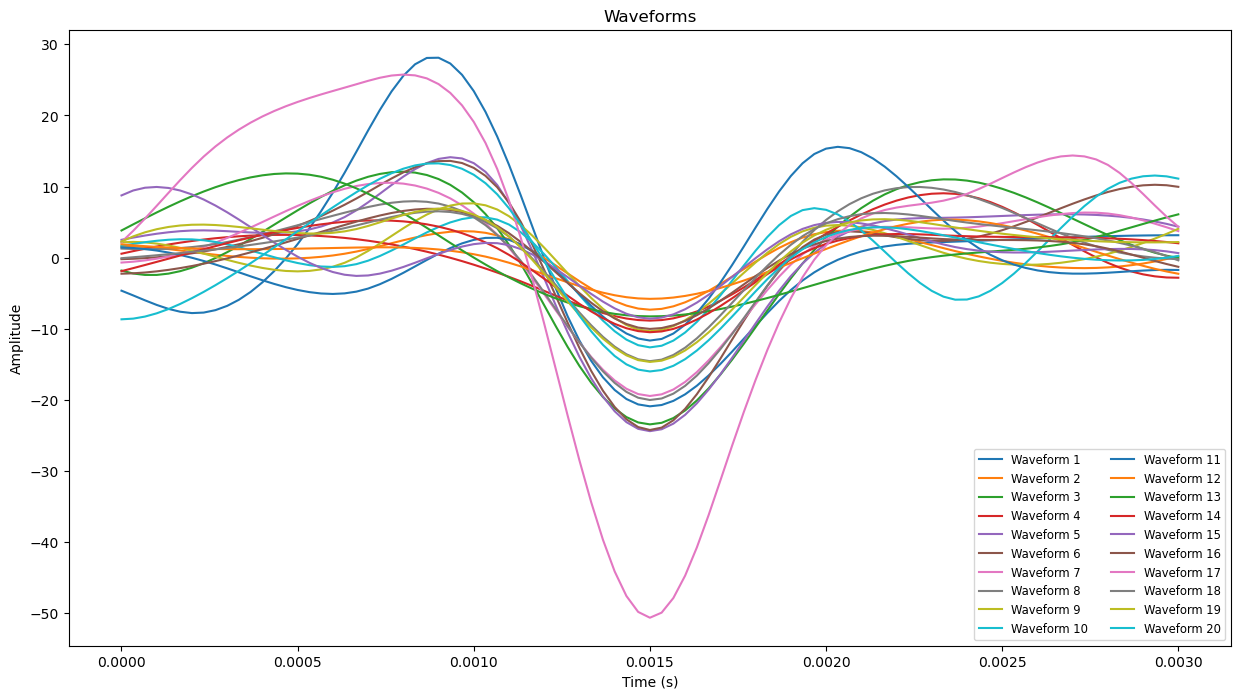

In [42]:
with h5py.File(hdf5_file, 'r') as f:
    # print(f["waveforms"])

    # Access the waveforms dataset
    waveforms = np.array(f['waveforms'])  # Shape should be (num_waveforms, waveform_length)
    print(f"Waveforms shape: {waveforms.shape}")

    # Select a subset of waveforms to visualize
    num_waveforms_to_plot = 20  # Adjust the number of waveforms to display
    selected_waveforms = waveforms[:num_waveforms_to_plot, :] 

    print(selected_waveforms.shape)
    time_points = np.arange(selected_waveforms.shape[1]) / sampling_rate

    # Plot the selected waveforms
    plt.figure(figsize=(15, 8))
    for i, waveform in enumerate(selected_waveforms):
        plt.plot(time_points, waveform, label=f'Waveform {i+1}')

    # Add labels, legend, and title
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Waveforms')
    plt.legend(loc='lower right', fontsize='small', ncol=2)
    plt.show()    

# Clusters.HDF5

In [35]:
hdf5_file = r"C:\Users\Ribhav\Desktop\UIUC\Classes\Git Repos\Work\MIV_Results\Data\skim449_RC_9_19_24\continuous.clusters.hdf5"

In [39]:
with h5py.File(hdf5_file, 'r') as f:
    print(f["electrodes"])
    print(np.array(f["electrodes"]))

<HDF5 dataset "electrodes": shape (171,), type "<i4">
[  0  80   1  81  81   2  82   3   3  83  83   4   4  84   5  85  85   6
   6  86   7  87  87   8  88   9   9  89  10  90  11  91  12  92  13  93
  93  14  94  15  95  16  96  17  17  97  18  98  19  99  99  20 100  21
  21 101 101  22 102 102  23 103  24 104  25 105 105  26 106 106  27 107
  28 108 108  29 109  30 110  31 111  32 112 112  33  33 113  34 114  35
 115  36 116 116  37 117 117  38 118  39  39 119  40  40 120 120  41  41
 121  42 122  43 123  44 124 124  45  45 125  46 126  47  47 127  48  49
  50  50  51  51  52  52  53  54  54  55  56  57  57  58  59  60  60  60
  61  61  62  63  64  65  66  67  68  68  69  70  70  71  71  72  73  73
  74  74  75  75  75  76  77  78  79]
